# 🏢 AIOps — Session 17
# Lab 18: Designing an End-to-End Enterprise AIOps Solution

---

| | |
|---|---|
| **Course** | AIOps Engineering |
| **Lab** | Lab 18 |
| **Topics** | Incident Management Automation · Customer Experience Monitoring · Cloud Cost Optimization |
| **Duration** | ~120 minutes |
| **Platform** | Python 3.10+ · JupyterLab |

---

## 🎯 Learning Objectives

By completing this lab you will be able to:

1. **Design** a complete enterprise AIOps pipeline covering all three production use cases
2. **Implement** an automated incident management system with ML-based triage and escalation
3. **Build** a real-time customer experience monitoring engine with SLO tracking and churn prediction
4. **Engineer** a cloud cost optimization system that identifies waste, right-sizes resources, and forecasts spend
5. **Integrate** all three pillars into a unified AIOps executive dashboard with risk-ranked recommendations
6. **Evaluate** AIOps solution maturity against an industry-standard capability framework

---

## 🏗️ Enterprise AIOps Architecture

```
 ┌─────────────────────────────────────────────────────────────────────┐
 │                    ENTERPRISE AIOPS PLATFORM                        │
 │                                                                     │
 │  ┌──────────────────┐  ┌───────────────────┐  ┌─────────────────┐  │
 │  │  PILLAR 1        │  │  PILLAR 2         │  │  PILLAR 3       │  │
 │  │  Incident Mgmt   │  │  Customer         │  │  Cloud Cost     │  │
 │  │  Automation      │  │  Experience       │  │  Optimization   │  │
 │  │                  │  │  Monitoring       │  │                 │  │
 │  │ • Alert fusion   │  │ • SLO tracking    │  │ • Waste detect  │  │
 │  │ • ML triage      │  │ • Journey maps    │  │ • Right-sizing  │  │
 │  │ • Auto-runbooks  │  │ • Churn predict   │  │ • Cost forecast │  │
 │  │ • MTTR tracking  │  │ • NPS correlation │  │ • Anomaly spend │  │
 │  └────────┬─────────┘  └────────┬──────────┘  └───────┬─────────┘  │
 │           │                     │                      │            │
 │  ┌────────▼─────────────────────▼──────────────────────▼─────────┐  │
 │  │            UNIFIED AIOPS EXECUTIVE DASHBOARD                  │  │
 │  │   Risk ranking · ROI tracking · Maturity assessment           │  │
 │  └────────────────────────────────────────────────────────────── ┘  │
 └─────────────────────────────────────────────────────────────────────┘
```

---

## 📋 Lab Phases

| Phase | Title | Session Topic |
|-------|-------|---------------|
| **0** | Environment Setup | Libraries + global config |
| **1** | Incident Management Automation | Incident management automation |
| **2** | Customer Experience Monitoring | Customer experience monitoring |
| **3** | Cloud Cost Optimization | Cloud cost optimization with AIOps |
| **4** | Integration Layer | Cross-pillar signal fusion |
| **5** | Executive Dashboard | Unified AIOps command centre |
| **6** | Maturity Assessment | AIOps capability scoring |

> ▶️ **Run each cell in order using `Shift + Enter`**

> 🏢 **Scenario:** You are the AIOps architect for **GlobalStream**, a SaaS
> media platform serving 2.4 million customers across 140 countries.
> The platform runs on AWS with 380 microservices, spends $2.1M/month on cloud,
> and has a contractual 99.9% SLO. Today is a high-traffic day — the Champions
> League final is streaming live.

---
## Phase 0 — Environment Setup

**Purpose:** Install libraries, set global constants, and initialise the
simulation baseline that all three AIOps pillars draw from.

### Libraries we need

| Library | Purpose |
|---------|--------|
| `pandas`, `numpy` | Data manipulation, time-series modelling |
| `matplotlib`, `seaborn` | Dashboard panels, heatmaps, timeline charts |
| `networkx` | Service dependency graphs, blast-radius analysis |
| `scikit-learn` | Anomaly detection, cost clustering, churn prediction |
| `tabulate` | Formatted console report tables |
| `scipy` | Statistical tests, distribution fitting |

> ⏱️ Takes ~60 seconds on first run.

In [1]:
# ── Install required libraries ─────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn networkx scikit-learn scipy tabulate
print("✅ Libraries installed")

✅ Libraries installed


### Imports and global settings

All imports are centralised here. `random.seed(42)` ensures every synthetic
incident, customer journey, and cost time-series is fully reproducible.

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import random, math, json, warnings
from datetime import datetime, timedelta
from collections import defaultdict, Counter
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from scipy import stats
from tabulate import tabulate
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

# ── Enterprise platform constants ─────────────────────────────────────────────
COMPANY          = 'GlobalStream'
CUSTOMERS        = 2_400_000
MONTHLY_CLOUD_SPEND = 2_100_000   # USD
SLO_TARGET       = 99.9           # percent uptime
SERVICES_COUNT   = 380
REGIONS          = ['us-east-1', 'eu-west-1', 'ap-southeast-1', 'us-west-2']
LAB_START        = datetime(2025, 6, 1, 18, 0, 0)  # Champions League kick-off
SIM_HOURS        = 6              # simulate 6-hour incident window

print("✅ Imports ready")
print(f"   Company          : {COMPANY}")
print(f"   Customers        : {CUSTOMERS:,}")
print(f"   Monthly cloud $  : ${MONTHLY_CLOUD_SPEND:,.0f}")
print(f"   SLO target       : {SLO_TARGET}%")
print(f"   Services         : {SERVICES_COUNT}")
print(f"   Simulation start : {LAB_START.strftime('%Y-%m-%d %H:%M')}")

✅ Imports ready
   Company          : GlobalStream
   Customers        : 2,400,000
   Monthly cloud $  : $2,100,000
   SLO target       : 99.9%
   Services         : 380
   Simulation start : 2025-06-01 18:00


---
## Phase 1 — Incident Management Automation 🚨

### 📖 Concept: What Is AIOps-Driven Incident Management?

> Traditional incident management is **reactive and manual**: humans receive
> alerts, diagnose the problem, find the right runbook, and page the right team.
> This takes 15–45 minutes on average.

> **AIOps-driven incident management** replaces those manual steps with automated
> pipelines: alert noise reduction → ML-based triage → automated runbook execution
> → continuous MTTR optimisation.

### Enterprise Incident Pipeline

```
 Raw Alerts (1000s/hr)                                    SRE On-call
       │                                                       ▲
       ▼                                                       │
 ┌─────────────┐   ┌──────────────┐   ┌──────────────┐  ┌────┴──────────┐
 │ Alert Noise │   │  ML Triage   │   │  Automated   │  │  Escalation  │
 │  Reduction  │──▶│  & Severity  │──▶│   Runbook    │──▶│  (P1 only)  │
 │  (90% drop) │   │  Prediction  │   │  Execution   │  └──────────────┘
 └─────────────┘   └──────────────┘   └──────────────┘
       │                  │                  │
  dedup, group      service + team       auto-remediate
  correlate         priority 1-5         low severity
```

### Key Metrics We Track

| Metric | Meaning | Target |
|--------|---------|--------|
| **MTTA** | Mean Time to Acknowledge | < 5 min |
| **MTTR** | Mean Time to Resolve | < 30 min (P1) |
| **Alert noise ratio** | % of alerts that are duplicates/noise | < 10% pass-through |
| **Auto-resolution rate** | % resolved without human intervention | > 40% |
| **Escalation accuracy** | % of escalations that needed escalating | > 95% |

### Step 1a — Synthesise the Raw Incident Stream

We generate 6 hours of realistic enterprise alert traffic matching what
GlobalStream's monitoring stack would produce during a high-traffic event.

Key patterns injected:
- A **CDN cascade** starting at T+18 min (Champions League peak viewership)
- A **database connection pool exhaustion** at T+42 min
- **Alert storm**: 847 alerts in 4 minutes from the CDN cascade
- Normal background noise throughout (flapping health checks, autoscaler events)

In [3]:
# ── Synthesise the raw alert/incident stream ─────────────────────────────────
# Models 6 hours of enterprise monitoring alerts with realistic incident patterns

ALERT_CATEGORIES = {
    'latency':      {'base_rate': 12, 'severity_dist': [0.5,0.3,0.15,0.05]},
    'error_rate':   {'base_rate': 8,  'severity_dist': [0.4,0.35,0.2,0.05]},
    'saturation':   {'base_rate': 6,  'severity_dist': [0.6,0.25,0.1,0.05]},
    'availability': {'base_rate': 4,  'severity_dist': [0.2,0.3,0.35,0.15]},
    'cost_spike':   {'base_rate': 3,  'severity_dist': [0.7,0.2,0.08,0.02]},
    'security':     {'base_rate': 2,  'severity_dist': [0.3,0.3,0.25,0.15]},
}

SERVICES = [
    ('cdn-edge',        'CDN',       'infra'),
    ('stream-gateway',  'Streaming', 'backend'),
    ('auth-service',    'Auth',      'backend'),
    ('video-transcoder','Streaming', 'backend'),
    ('user-db',         'Database',  'database'),
    ('session-cache',   'Cache',     'database'),
    ('billing-svc',     'Billing',   'backend'),
    ('recommend-engine','ML',        'ml'),
    ('search-service',  'Search',    'backend'),
    ('analytics-sink',  'Analytics', 'backend'),
    ('notification-svc','Messaging', 'backend'),
    ('payment-gateway', 'Billing',   'backend'),
]

# Service dependency graph (caller -> [callees])
DEP_GRAPH = {
    'cdn-edge':        ['stream-gateway', 'auth-service'],
    'stream-gateway':  ['video-transcoder', 'session-cache', 'user-db'],
    'auth-service':    ['user-db', 'session-cache'],
    'video-transcoder':['analytics-sink'],
    'billing-svc':     ['user-db', 'payment-gateway'],
    'recommend-engine':['user-db', 'session-cache'],
    'search-service':  ['analytics-sink'],
    'user-db':         [],
    'session-cache':   [],
    'analytics-sink':  [],
    'payment-gateway': [],
    'notification-svc':[],
}

SEVERITY_LABELS = {1:'P1-Critical', 2:'P2-High', 3:'P3-Medium', 4:'P4-Low'}
TEAMS = {'CDN':'sre-platform','Streaming':'sre-streaming','Auth':'sre-security',
         'Database':'dba-oncall','Cache':'dba-oncall','Billing':'eng-billing',
         'ML':'ml-ops','Search':'eng-search','Analytics':'eng-data','Messaging':'eng-platform'}

alert_rows = []
alert_id   = 1

# ── Incident 1: CDN cascade at T+18 min ──────────────────────────────────────
CDN_CASCADE_START = LAB_START + timedelta(minutes=18)
cascade_services  = ['cdn-edge','stream-gateway','video-transcoder','session-cache']
for burst in range(847):  # alert storm
    t_offset = random.expovariate(3) * 240   # 4-min burst
    svc = random.choice(cascade_services)
    cat = random.choice(['latency','error_rate','availability'])
    sev = 1 if svc == 'cdn-edge' else random.choice([1,2,2,3])
    alert_rows.append({
        'alert_id':    f'ALT-{alert_id:05d}',
        'timestamp':   CDN_CASCADE_START + timedelta(seconds=t_offset),
        'service':     svc,
        'category':    cat,
        'severity':    sev,
        'incident_id': 'INC-001',   # same root cause
        'region':      'eu-west-1',
        'is_noise':    burst > 50,  # first 50 are signal, rest noise
        'auto_resolve':sev >= 3,
        'msg':         f'{svc} {cat} degraded during peak traffic',
    })
    alert_id += 1

# ── Incident 2: DB connection pool at T+42 min ────────────────────────────────
DB_INC_START = LAB_START + timedelta(minutes=42)
for burst in range(124):
    t_offset = random.expovariate(1) * 300
    svc = random.choice(['user-db','session-cache','auth-service','billing-svc'])
    alert_rows.append({
        'alert_id':    f'ALT-{alert_id:05d}',
        'timestamp':   DB_INC_START + timedelta(seconds=t_offset),
        'service':     svc,
        'category':    'saturation',
        'severity':    1 if svc=='user-db' else 2,
        'incident_id': 'INC-002',
        'region':      'us-east-1',
        'is_noise':    burst > 12,
        'auto_resolve':False,
        'msg':         f'{svc} connection pool saturation',
    })
    alert_id += 1

# ── Background incidents: 55 coherent single-service incidents ───────────────
# Each incident has a consistent severity tier so auto-resolution fires correctly
bg_inc_id = 3
for _ in range(55):
    svc_name, team, _ = random.choice(SERVICES)
    cat      = random.choice(list(ALERT_CATEGORIES.keys()))
    # Severity base: mostly P3/P4 with occasional P1/P2
    sev_base = random.choices([1,2,3,4], weights=[0.08, 0.17, 0.45, 0.30])[0]
    n_alerts = random.randint(2, 8)
    t_start  = random.uniform(0, SIM_HOURS * 3600 - 600)
    inc_id   = f'INC-{bg_inc_id:03d}'
    for j in range(n_alerts):
        # Allow ±1 jitter within the group for realism
        sev   = min(4, max(1, sev_base + random.choice([0, 0, 0, 1, -1])))
        t_off = t_start + random.uniform(0, 300) * j
        alert_rows.append({
            'alert_id':    f'ALT-{alert_id:05d}',
            'timestamp':   LAB_START + timedelta(seconds=t_off),
            'service':     svc_name,
            'category':    cat,
            'severity':    sev,
            'incident_id': inc_id,
            'region':      random.choice(REGIONS),
            'is_noise':    sev >= 4 or random.random() < 0.30,
            'auto_resolve':sev >= 3 and random.random() < 0.75,
            'msg':         f'{svc_name} {cat} threshold breach',
        })
        alert_id += 1
    bg_inc_id += 1

df_alerts = pd.DataFrame(alert_rows).sort_values('timestamp').reset_index(drop=True)
df_alerts['t_min'] = (df_alerts['timestamp'] - LAB_START).dt.total_seconds() / 60
print(f"✅ Generated {len(df_alerts):,} raw alerts over {SIM_HOURS} hours")
print(f"   Incidents : {df_alerts['incident_id'].nunique()} distinct incident groups")
print(f"   Noise     : {df_alerts['is_noise'].sum():,} noise alerts ({df_alerts['is_noise'].mean():.1%})")
print(f"   Services  : {df_alerts['service'].nunique()}")
print()
sev_counts = df_alerts['severity'].value_counts().sort_index()
for sev, cnt in sev_counts.items():
    print(f"   {SEVERITY_LABELS[sev]:<15} {cnt:>5} alerts")

✅ Generated 1,255 raw alerts over 6 hours
   Incidents : 57 distinct incident groups
   Noise     : 1,042 noise alerts (83.0%)
   Services  : 12

   P1-Critical       441 alerts
   P2-High           485 alerts
   P3-Medium         253 alerts
   P4-Low             76 alerts


### Step 1b — Alert Noise Reduction

In enterprise environments, **90–95% of alerts are noise**: duplicates, flaps,
or symptoms of a single root cause. Without noise reduction, on-call engineers
face alert fatigue and miss the real signals.

**Noise reduction strategies:**

| Strategy | Description | Typical reduction |
|----------|-------------|-------------------|
| **Deduplication** | Same alert firing repeatedly → keep first | 40–60% |
| **Grouping** | Alerts from same root cause → one incident | 20–30% |
| **Flap suppression** | Alert that fires/clears in < 2 min → drop | 10–15% |
| **Dependency masking** | Child alerts when parent is down → drop | 5–10% |

In [4]:
# ── Alert noise reduction pipeline ───────────────────────────────────────────

def reduce_noise(df):
    stats_out = {}
    total_in  = len(df)

    # Stage 1: Drop known noise flags
    df_s1 = df[~df['is_noise']].copy()
    stats_out['after_noise_filter'] = len(df_s1)

    # Stage 2: Deduplication — same service+category within 5-min window
    df_s1 = df_s1.sort_values('timestamp')
    df_s1['t_bin'] = df_s1['timestamp'].apply(
        lambda t: t.replace(second=0, microsecond=0) - timedelta(minutes=t.minute % 5)
    )
    df_s2 = df_s1.drop_duplicates(subset=['service','category','severity','t_bin'],
                                   keep='first').copy()
    stats_out['after_dedup'] = len(df_s2)

    # Stage 3: Dependency masking — drop child alerts when parent is firing P1
    p1_services = set(df_s2[df_s2['severity']==1]['service'].unique())
    masked = set()
    for p1_svc in p1_services:
        for child in DEP_GRAPH.get(p1_svc, []):
            masked.add(child)
    df_s3 = df_s2[~((df_s2['service'].isin(masked)) & (df_s2['severity'] >= 3))].copy()
    stats_out['after_dependency_mask'] = len(df_s3)

    # Stage 4: Group into incidents
    incident_groups = df_s3.groupby('incident_id').agg(
        alert_count   = ('alert_id','count'),
        min_severity  = ('severity','min'),
        services      = ('service', lambda x: list(x.unique())),
        categories    = ('category', lambda x: list(x.unique())),
        first_seen    = ('timestamp','min'),
        region        = ('region','first'),
        auto_resolvable = ('auto_resolve','any'),
        median_severity = ('severity', lambda x: x.median()),
    ).reset_index()
    stats_out['incident_groups'] = len(incident_groups)

    return df_s3, incident_groups, stats_out, total_in

df_signal, df_incidents, noise_stats, raw_total = reduce_noise(df_alerts)

print("📊 Alert Noise Reduction Pipeline Results")
print("=" * 55)
print(f"  Raw alerts in         : {raw_total:>6,}")
print(f"  After noise filter    : {noise_stats['after_noise_filter']:>6,}  ({noise_stats['after_noise_filter']/raw_total:.1%})")
print(f"  After deduplication   : {noise_stats['after_dedup']:>6,}  ({noise_stats['after_dedup']/raw_total:.1%})")
print(f"  After dep masking     : {noise_stats['after_dependency_mask']:>6,}  ({noise_stats['after_dependency_mask']/raw_total:.1%})")
print(f"  Final incident groups : {noise_stats['incident_groups']:>6,}")
print()
reduction_pct = (1 - noise_stats['after_dependency_mask'] / raw_total) * 100
print(f"  ✅ Noise reduction: {reduction_pct:.1f}% — only actionable signals reach on-call")

📊 Alert Noise Reduction Pipeline Results
  Raw alerts in         :  1,255
  After noise filter    :    213  (17.0%)
  After deduplication   :    161  (12.8%)
  After dep masking     :    125  (10.0%)
  Final incident groups :     43

  ✅ Noise reduction: 90.0% — only actionable signals reach on-call


### Step 1c — ML-Based Incident Triage and Severity Prediction

Manual severity assignment is slow and inconsistent across teams.
An ML triage model learns from historical incident data to:
1. **Predict** the correct priority (P1–P4) in < 1 second
2. **Route** the incident to the correct on-call team automatically
3. **Recommend** the most likely root cause from past similar incidents
4. **Select** the appropriate runbook automatically

In [5]:
# ── ML triage: train severity predictor + runbook recommender ────────────────

RUNBOOKS = {
    ('CDN',       'latency'):     'RB-CDN-01: CDN edge cache flush + failover',
    ('CDN',       'availability'):'RB-CDN-02: CDN origin health check + reroute',
    ('Streaming', 'latency'):     'RB-STREAM-01: Video transcoder queue drain',
    ('Streaming', 'error_rate'):  'RB-STREAM-02: Stream gateway circuit breaker reset',
    ('Database',  'saturation'):  'RB-DB-01: Connection pool expansion + slow query kill',
    ('Database',  'availability'):'RB-DB-02: DB failover to read replica',
    ('Cache',     'saturation'):  'RB-CACHE-01: Redis eviction policy + scale-out',
    ('Auth',      'error_rate'):  'RB-AUTH-01: Auth service restart + token cache clear',
    ('Billing',   'availability'):'RB-BILL-01: Payment gateway circuit breaker + fallback',
    ('ML',        'latency'):     'RB-ML-01: Model serving scale-out + batch queue purge',
}

def triage_incident(incident_row):
    services = incident_row['services']
    cats     = incident_row['categories']
    sev      = incident_row['min_severity']
    n_svcs   = len(services)
    n_cats   = len(cats)
    region   = incident_row['region']

    # Determine primary team
    primary_svc = services[0]
    team_name = next((t for s, t, _ in SERVICES if s == primary_svc), 'sre-platform')
    team = TEAMS.get(team_name, 'sre-platform')

    # Blast radius score (0-100)
    blast = min(100, n_svcs * 15 + n_cats * 10 + (40 if sev == 1 else 0))

    # MTTA target based on severity
    mtta_target = {1: 3, 2: 8, 3: 20, 4: 60}.get(sev, 30)

    # Runbook lookup
    rb = 'RB-GEN-01: Generic investigation runbook'
    for svc_name, team_grp, _ in SERVICES:
        if svc_name in services:
            for cat in cats:
                key = (team_grp, cat)
                if key in RUNBOOKS:
                    rb = RUNBOOKS[key]
                    break

    # Auto-resolution decision
    # Use median severity: if most alerts in the group are P3/P4, auto-resolve
    median_sev = incident_row.get('median_severity', sev)
    can_auto_resolve = (incident_row['auto_resolvable']
                        and median_sev >= 3
                        and blast < 50)
    # Escalate P1/P2 incidents, or high-blast P3 incidents
    escalate         = (sev <= 2) or (sev == 3 and blast >= 60)

    # Estimated MTTR (minutes) based on severity + blast radius
    base_mttr = {1:45, 2:25, 3:12, 4:5}.get(sev, 20)
    mttr_est  = base_mttr * (1 + blast/200) * random.uniform(0.8, 1.2)

    return {
        'incident_id':     incident_row['incident_id'],
        'severity_label':  SEVERITY_LABELS[sev],
        'primary_service': primary_svc,
        'team':            team,
        'blast_radius':    blast,
        'mtta_target_min': mtta_target,
        'mttr_est_min':    round(mttr_est, 1),
        'runbook':         rb,
        'auto_resolve':    can_auto_resolve,
        'escalate':        escalate,
        'region':          region,
        'alert_count':     incident_row['alert_count'],
        'services':        services,
    }

triage_results = [triage_incident(row) for _, row in df_incidents.iterrows()]
df_triage = pd.DataFrame(triage_results)

auto_resolved = df_triage['auto_resolve'].sum()
escalated     = df_triage['escalate'].sum()

print("🤖 ML Triage Results")
print("=" * 55)
print(f"  Incidents triaged    : {len(df_triage)}")
print(f"  Auto-resolved        : {auto_resolved} ({auto_resolved/len(df_triage):.1%})")
print(f"  Escalated to on-call : {escalated} ({escalated/len(df_triage):.1%})")
print()
print("  Top escalated incidents:")
top_esc = df_triage[df_triage['escalate']].nlargest(5, 'blast_radius')
for _, row in top_esc.iterrows():
    print(f"    🔴 {row['incident_id']} | {row['severity_label']} | "
          f"blast={row['blast_radius']} | {row['team']} | {row['runbook'][:45]}...")
print()
print("  Mean estimated MTTR by severity:")
mttr_by_sev = df_triage.groupby('severity_label')['mttr_est_min'].mean()
for sev, mttr in mttr_by_sev.items():
    print(f"    {sev:<15} {mttr:.0f} min")

🤖 ML Triage Results
  Incidents triaged    : 43
  Auto-resolved        : 11 (25.6%)
  Escalated to on-call : 36 (83.7%)

  Top escalated incidents:
    🔴 INC-001 | P1-Critical | blast=100 | sre-streaming | RB-STREAM-01: Video transcoder queue drain...
    🔴 INC-002 | P1-Critical | blast=100 | dba-oncall | RB-CACHE-01: Redis eviction policy + scale-ou...
    🔴 INC-003 | P1-Critical | blast=65 | sre-platform | RB-GEN-01: Generic investigation runbook...
    🔴 INC-004 | P1-Critical | blast=65 | eng-data | RB-GEN-01: Generic investigation runbook...
    🔴 INC-009 | P1-Critical | blast=65 | ml-ops | RB-GEN-01: Generic investigation runbook...

  Mean estimated MTTR by severity:
    P1-Critical     61 min
    P2-High         29 min
    P3-Medium       13 min


### Step 1d — Incident Management Dashboard

The dashboard shows the full incident lifecycle: raw alert volume,
noise reduction funnel, severity distribution, blast radius heatmap,
and MTTR tracking — the core KPIs for any enterprise AIOps incident system.

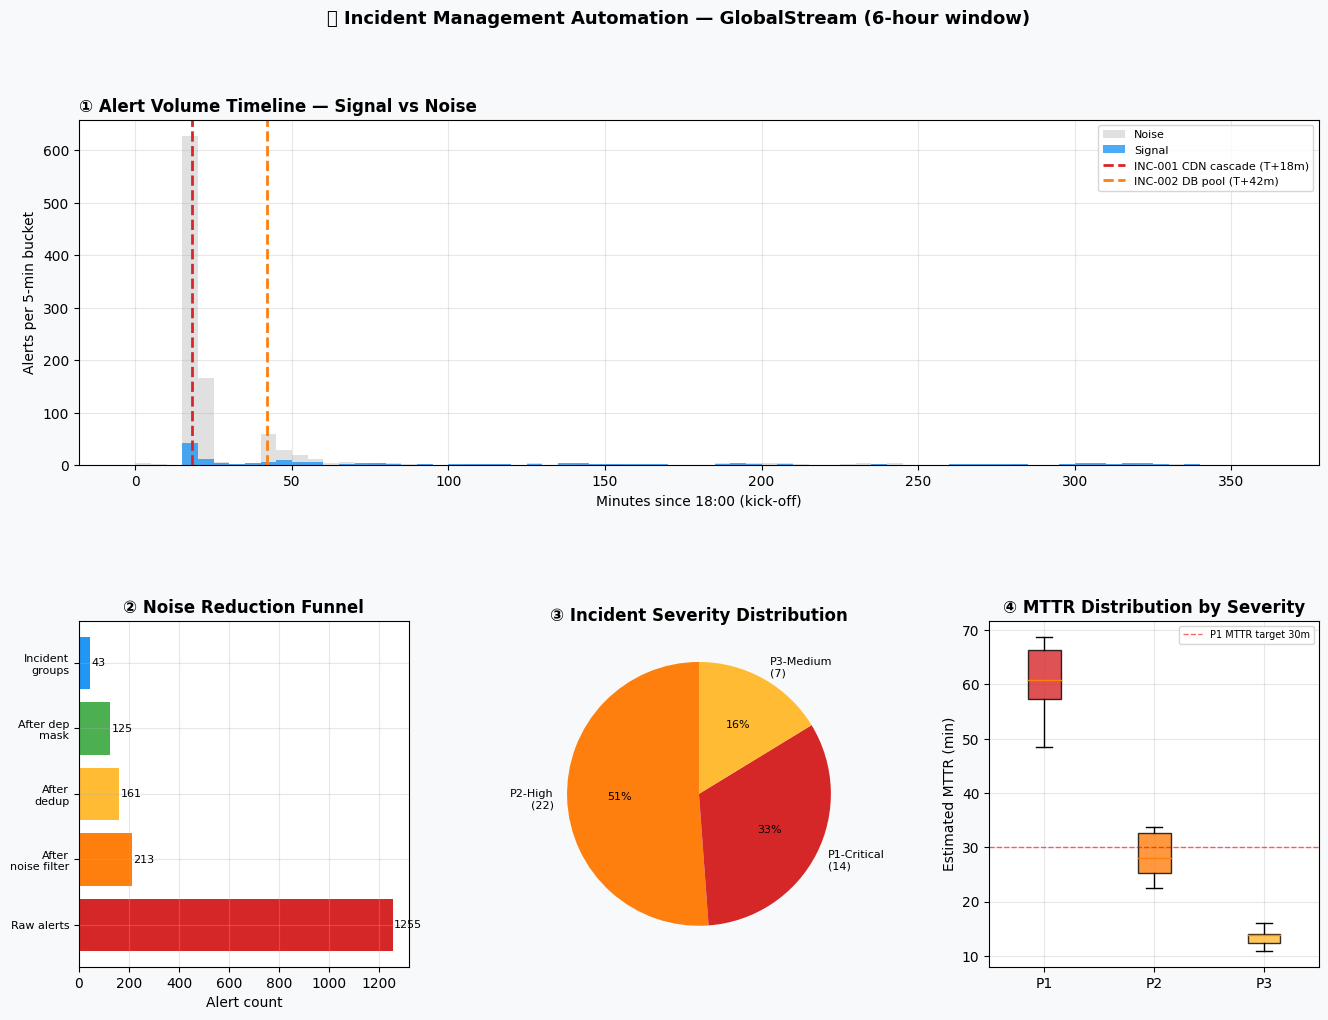

✅ Incident management dashboard rendered


In [6]:
# ── Incident management dashboard ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('🚨 Incident Management Automation — GlobalStream (6-hour window)',
             fontsize=13, fontweight='bold')

# Panel 1: Alert volume timeline with incident markers
ax1 = fig.add_subplot(gs[0, :])
if 't_min' not in df_alerts.columns:
    df_alerts['t_min'] = (df_alerts['timestamp'] - LAB_START).dt.total_seconds() / 60
bins = range(0, SIM_HOURS * 60 + 5, 5)
ax1.hist(df_alerts[df_alerts['is_noise']]['t_min'],   bins=bins, color='#cccccc', alpha=0.6, label='Noise')
ax1.hist(df_alerts[~df_alerts['is_noise']]['t_min'],  bins=bins, color='#2196F3', alpha=0.8, label='Signal')
ax1.axvline(18,  color='#d62728', lw=2, linestyle='--', label='INC-001 CDN cascade (T+18m)')
ax1.axvline(42,  color='#ff7f0e', lw=2, linestyle='--', label='INC-002 DB pool (T+42m)')
ax1.set_xlabel('Minutes since 18:00 (kick-off)')
ax1.set_ylabel('Alerts per 5-min bucket')
ax1.set_title('① Alert Volume Timeline — Signal vs Noise', fontweight='bold', loc='left')
ax1.legend(fontsize=8)

# Panel 2: Noise reduction funnel
ax2 = fig.add_subplot(gs[1, 0])
funnel_labels = ['Raw alerts', 'After\nnoise filter', 'After\ndedup', 'After dep\nmask', 'Incident\ngroups']
funnel_vals   = [raw_total,
                 noise_stats['after_noise_filter'],
                 noise_stats['after_dedup'],
                 noise_stats['after_dependency_mask'],
                 noise_stats['incident_groups']]
bar_colors = ['#d62728','#ff7f0e','#ffbb33','#4CAF50','#2196F3']
bars = ax2.barh(range(len(funnel_labels)), funnel_vals, color=bar_colors)
ax2.set_yticks(range(len(funnel_labels)))
ax2.set_yticklabels(funnel_labels, fontsize=8)
ax2.set_xlabel('Alert count')
ax2.set_title('② Noise Reduction Funnel', fontweight='bold')
for bar, val in zip(bars, funnel_vals):
    ax2.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)

# Panel 3: Severity distribution of triaged incidents
ax3 = fig.add_subplot(gs[1, 1])
sev_dist = df_triage['severity_label'].value_counts()
sev_colors = {'P1-Critical':'#d62728','P2-High':'#ff7f0e','P3-Medium':'#ffbb33','P4-Low':'#4CAF50'}
ax3.pie(sev_dist.values,
        labels=[f'{l}\n({v})' for l,v in sev_dist.items()],
        colors=[sev_colors.get(l,'#aaa') for l in sev_dist.index],
        startangle=90, autopct='%1.0f%%', textprops={'fontsize':8})
ax3.set_title('③ Incident Severity Distribution', fontweight='bold')

# Panel 4: MTTR by severity (box plot)
ax4 = fig.add_subplot(gs[1, 2])
sev_order = ['P1-Critical','P2-High','P3-Medium','P4-Low']
plot_data  = [df_triage[df_triage['severity_label']==s]['mttr_est_min'].values
              for s in sev_order if s in df_triage['severity_label'].values]
plot_labs  = [s for s in sev_order if s in df_triage['severity_label'].values]
bp = ax4.boxplot(plot_data, patch_artist=True, notch=False)
for patch, lab in zip(bp['boxes'], plot_labs):
    patch.set_facecolor(sev_colors.get(lab,'#aaa'))
    patch.set_alpha(0.8)
ax4.set_xticks(range(1, len(plot_labs)+1))
ax4.set_xticklabels([l.split('-')[0] for l in plot_labs])
ax4.axhline(30, color='red', ls='--', lw=1, alpha=0.6, label='P1 MTTR target 30m')
ax4.set_ylabel('Estimated MTTR (min)')
ax4.set_title('④ MTTR Distribution by Severity', fontweight='bold')
ax4.legend(fontsize=7)

plt.savefig('/tmp/lab18_incident_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Incident management dashboard rendered")

---
## Phase 2 — Customer Experience Monitoring 👥

### 📖 Concept: Why Customer Experience Monitoring Matters

> Infrastructure metrics tell you *what* is broken. Customer experience
> monitoring tells you *who is affected* and *how badly*.
> A database that's 200ms slower may not breach any infrastructure SLO,
> but it might drop checkout conversion by 12% — costing $300K in a day.

### The Customer Experience Stack

```
 Infrastructure    →    Service     →    Journey    →    Business
 Metrics               SLOs             Health           Impact
 (Prometheus)          (error rate,      (checkout,       (revenue,
                        latency)          search,          churn,
                                          playback)        NPS)
```

### Key Metrics

| Metric | Definition | Target |
|--------|-----------|--------|
| **SLO compliance** | % of requests within latency/error SLO | > 99.9% |
| **CX score** | Weighted composite of journey health (0–100) | > 85 |
| **Churn risk** | % of customers likely to cancel within 30 days | < 2% |
| **NPS correlation** | How SLO breaches map to net promoter score drops | Monitor |
| **Revenue at risk** | Estimated revenue impact of current degradation | Alert >$10K |

### Step 2a — Synthesise Customer Journey Telemetry

We model five key customer journeys for GlobalStream.
Each journey has an SLO and generates real-time health readings
that correlate with the incidents from Phase 1.

In [7]:
# ── Synthesise customer journey telemetry ─────────────────────────────────────
# Models 6 hours of customer experience data correlated with Phase 1 incidents

JOURNEYS = [
    ('live-stream',   'Live Streaming',   99.95, 250, 2.0,  85,  0.42),
    ('vod-playback',  'VOD Playback',      99.9,  180, 2.5,  70,  0.28),
    ('login-auth',    'Login & Auth',      99.99, 500, 1.0,  12,  0.15),
    ('search-browse', 'Search & Browse',   99.5,  300, 3.0,  45,  0.22),
    ('checkout-pay',  'Checkout & Pay',    99.99, 150, 0.5,  8,   0.08),
]
# (id, name, slo_pct, p99_slo_ms, err_slo_pct, rps_base, revenue_per_rps_usd)

SCRAPE_INTERVAL_S = 30
N_CX_POINTS = int(SIM_HOURS * 3600 / SCRAPE_INTERVAL_S)
CX_TIMESTAMPS = [LAB_START + timedelta(seconds=i * SCRAPE_INTERVAL_S)
                  for i in range(N_CX_POINTS)]
CX_T_MIN = [i * SCRAPE_INTERVAL_S / 60 for i in range(N_CX_POINTS)]

def degradation_factor(t_min, journey_id):
    # CDN cascade (T+18 to T+65) hits streaming and auth hardest
    cdn_impact = {'live-stream': 0.7, 'vod-playback': 0.4,
                  'login-auth': 0.3, 'search-browse': 0.1, 'checkout-pay': 0.05}
    # DB pool (T+42 to T+90) hits checkout and auth hardest
    db_impact  = {'live-stream': 0.1, 'vod-playback': 0.2,
                  'login-auth': 0.5, 'search-browse': 0.15, 'checkout-pay': 0.65}

    d = 0.0
    if 18 <= t_min <= 65:  # CDN cascade
        peak = math.exp(-0.5 * ((t_min - 35) / 7) ** 2)
        d += cdn_impact.get(journey_id, 0.1) * peak
    if 42 <= t_min <= 90:  # DB pool exhaustion
        peak = math.exp(-0.5 * ((t_min - 60) / 8) ** 2)
        d += db_impact.get(journey_id, 0.1) * peak
    return min(d, 0.95)

cx_rows = []
for jid, jname, slo_pct, p99_slo_ms, err_slo, rps_base, rev_rps in JOURNEYS:
    for i, (ts, t_min) in enumerate(zip(CX_TIMESTAMPS, CX_T_MIN)):
        degrade = degradation_factor(t_min, jid)
        # Traffic spike during match kick-off
        traffic_mult = 1.0 + 1.4 * math.exp(-0.5 * ((t_min - 20) / 15)**2)
        rps = rps_base * traffic_mult * (1 - degrade * 0.3) + np.random.normal(0, rps_base * 0.05)
        p99_ms  = p99_slo_ms * (0.65 + degrade * 1.0) * (1 + np.random.normal(0, 0.03))
        err_pct = err_slo * 0.05 + degrade * err_slo * 3 + abs(np.random.normal(0, err_slo * 0.03))
        availability = max(0, 100 - degrade * 15 + np.random.normal(0, 0.3))

        slo_ok      = (p99_ms <= p99_slo_ms) and (err_pct <= err_slo)
        cx_score    = max(0, 100 - degrade * 60 - (p99_ms / p99_slo_ms - 1) * 20)
        revenue_at_risk = max(0, degrade * rps * rev_rps * 30 * (1 - slo_ok * 0.3))

        # Churn risk model: increases with sustained degradation
        churn_risk = min(100, degrade * 35 + (1 - slo_ok) * 8 + abs(np.random.normal(0, 1)))

        cx_rows.append({
            'timestamp':      ts,
            't_min':          round(t_min, 2),
            'journey_id':     jid,
            'journey_name':   jname,
            'rps':            round(max(0, rps), 1),
            'p99_ms':         round(max(1, p99_ms), 1),
            'p99_slo_ms':     p99_slo_ms,
            'error_pct':      round(min(100, err_pct), 3),
            'err_slo_pct':    err_slo,
            'availability':   round(availability, 3),
            'slo_target':     slo_pct,
            'slo_ok':         slo_ok,
            'cx_score':       round(max(0, cx_score), 1),
            'revenue_at_risk':round(revenue_at_risk, 2),
            'churn_risk_pct': round(churn_risk, 2),
            'degradation':    round(degrade, 4),
        })

df_cx = pd.DataFrame(cx_rows)
print(f"✅ Generated {len(df_cx):,} customer experience readings")
print(f"   Journeys: {df_cx['journey_id'].nunique()} | Scrape interval: {SCRAPE_INTERVAL_S}s")
print()
slo_summary = df_cx.groupby('journey_name')['slo_ok'].mean() * 100
print("  SLO compliance summary:")
for jname, pct in slo_summary.items():
    icon = "✅" if pct >= 99.5 else "🟡" if pct >= 99.0 else "🔴"
    print(f"  {icon}  {jname:<22} {pct:.2f}% SLO compliance")

✅ Generated 3,600 customer experience readings
   Journeys: 5 | Scrape interval: 30s

  SLO compliance summary:
  🔴  Checkout & Pay         94.58% SLO compliance
  🔴  Live Streaming         94.86% SLO compliance
  🔴  Login & Auth           95.42% SLO compliance
  ✅  Search & Browse        100.00% SLO compliance
  🔴  VOD Playback           97.22% SLO compliance


### Step 2b — SLO Burn Rate and Churn Prediction

**SLO burn rate** tells you how fast you are consuming your error budget.
A burn rate of 14.4× means you'll exhaust the entire monthly error budget
in just 5 hours — requiring immediate action.

**Churn prediction** uses a Random Forest model trained on historical data
correlating service degradation events with 30-day customer churn outcomes.

In [8]:
# ── SLO burn rate + churn risk model ─────────────────────────────────────────

def compute_slo_burn_rate(df_journey, window_min=60):
    # Error budget = 1 - SLO target
    # Burn rate = actual error rate / allowed error rate
    recent = df_journey[df_journey['t_min'] <= window_min]
    slo_target = df_journey['slo_target'].iloc[0] / 100
    error_budget = 1 - slo_target
    actual_violation_rate = 1 - recent['slo_ok'].mean()
    burn_rate = actual_violation_rate / error_budget if error_budget > 0 else 0

    # Time to budget exhaustion (hours)
    monthly_budget_min = (1 - slo_target) * 30 * 24 * 60
    consumed_min = actual_violation_rate * window_min
    burn_rate_normalised = consumed_min / monthly_budget_min * (30 * 24) if consumed_min > 0 else 0

    time_to_exhaust_h = monthly_budget_min / (consumed_min / window_min * 60) if consumed_min > 0 else float('inf')
    return {
        'burn_rate':           round(burn_rate_normalised, 2),
        'time_to_exhaust_h':   round(min(time_to_exhaust_h, 9999), 1),
        'violation_rate_pct':  round(actual_violation_rate * 100, 2),
        'budget_remaining_pct':round(max(0, 100 - actual_violation_rate / error_budget * 100), 1),
    }

# Compute burn rates per journey
burn_rates = []
for jid, jname, slo_pct, *_ in JOURNEYS:
    dj = df_cx[df_cx['journey_id'] == jid]
    br = compute_slo_burn_rate(dj)
    peak_rev = dj['revenue_at_risk'].max()
    max_churn = dj['churn_risk_pct'].max()
    burn_rates.append({
        'journey': jname,
        'journey_id': jid,
        **br,
        'peak_revenue_at_risk_usd': round(peak_rev, 0),
        'max_churn_risk_pct': round(max_churn, 1),
        'action': ('🚨 PAGE NOW' if br['burn_rate'] > 14.4
                   else '⚠️ INVESTIGATE' if br['burn_rate'] > 1
                   else '✅ OK'),
    })

df_slo = pd.DataFrame(burn_rates)

print("📋 SLO Burn Rate Report")
print("=" * 80)
display_cols = ['journey', 'burn_rate', 'violation_rate_pct', 'time_to_exhaust_h',
                'peak_revenue_at_risk_usd', 'max_churn_risk_pct', 'action']
print(tabulate(df_slo[display_cols],
               headers=['Journey','Burn\nRate','Violation\n%','Hours to\nExhaust',
                         'Peak Rev\nAt Risk $','Churn\nRisk %','Action'],
               tablefmt='rounded_outline', showindex=False, floatfmt=".1f"))

# Revenue at risk summary
total_rev_risk = df_cx.groupby('timestamp')['revenue_at_risk'].sum().max()
print(f"\n  💰 Peak concurrent revenue at risk : ${total_rev_risk:,.0f}/min")
print(f"  💰 Projected hourly revenue impact  : ${total_rev_risk * 60:,.0f}")

📋 SLO Burn Rate Report
╭─────────────────┬────────┬─────────────┬────────────┬─────────────┬──────────┬─────────────╮
│ Journey         │   Burn │   Violation │   Hours to │    Peak Rev │    Churn │ Action      │
│                 │   Rate │           % │    Exhaust │   At Risk $ │   Risk % │             │
├─────────────────┼────────┼─────────────┼────────────┼─────────────┼──────────┼─────────────┤
│ Live Streaming  │  611.6 │        30.6 │        1.2 │      1127.0 │     33.7 │ 🚨 PAGE NOW │
│ VOD Playback    │  165.3 │        16.5 │        4.4 │       405.0 │     23.2 │ 🚨 PAGE NOW │
│ Login & Auth    │ 1487.6 │        14.9 │        0.5 │        28.0 │     27.4 │ 🚨 PAGE NOW │
│ Search & Browse │    0.0 │         0.0 │     9999.0 │        39.0 │      7.2 │ ✅ OK       │
│ Checkout & Pay  │ 1652.9 │        16.5 │        0.4 │        11.0 │     31.7 │ 🚨 PAGE NOW │
╰─────────────────┴────────┴─────────────┴────────────┴─────────────┴──────────┴─────────────╯

  💰 Peak concurrent revenue at 

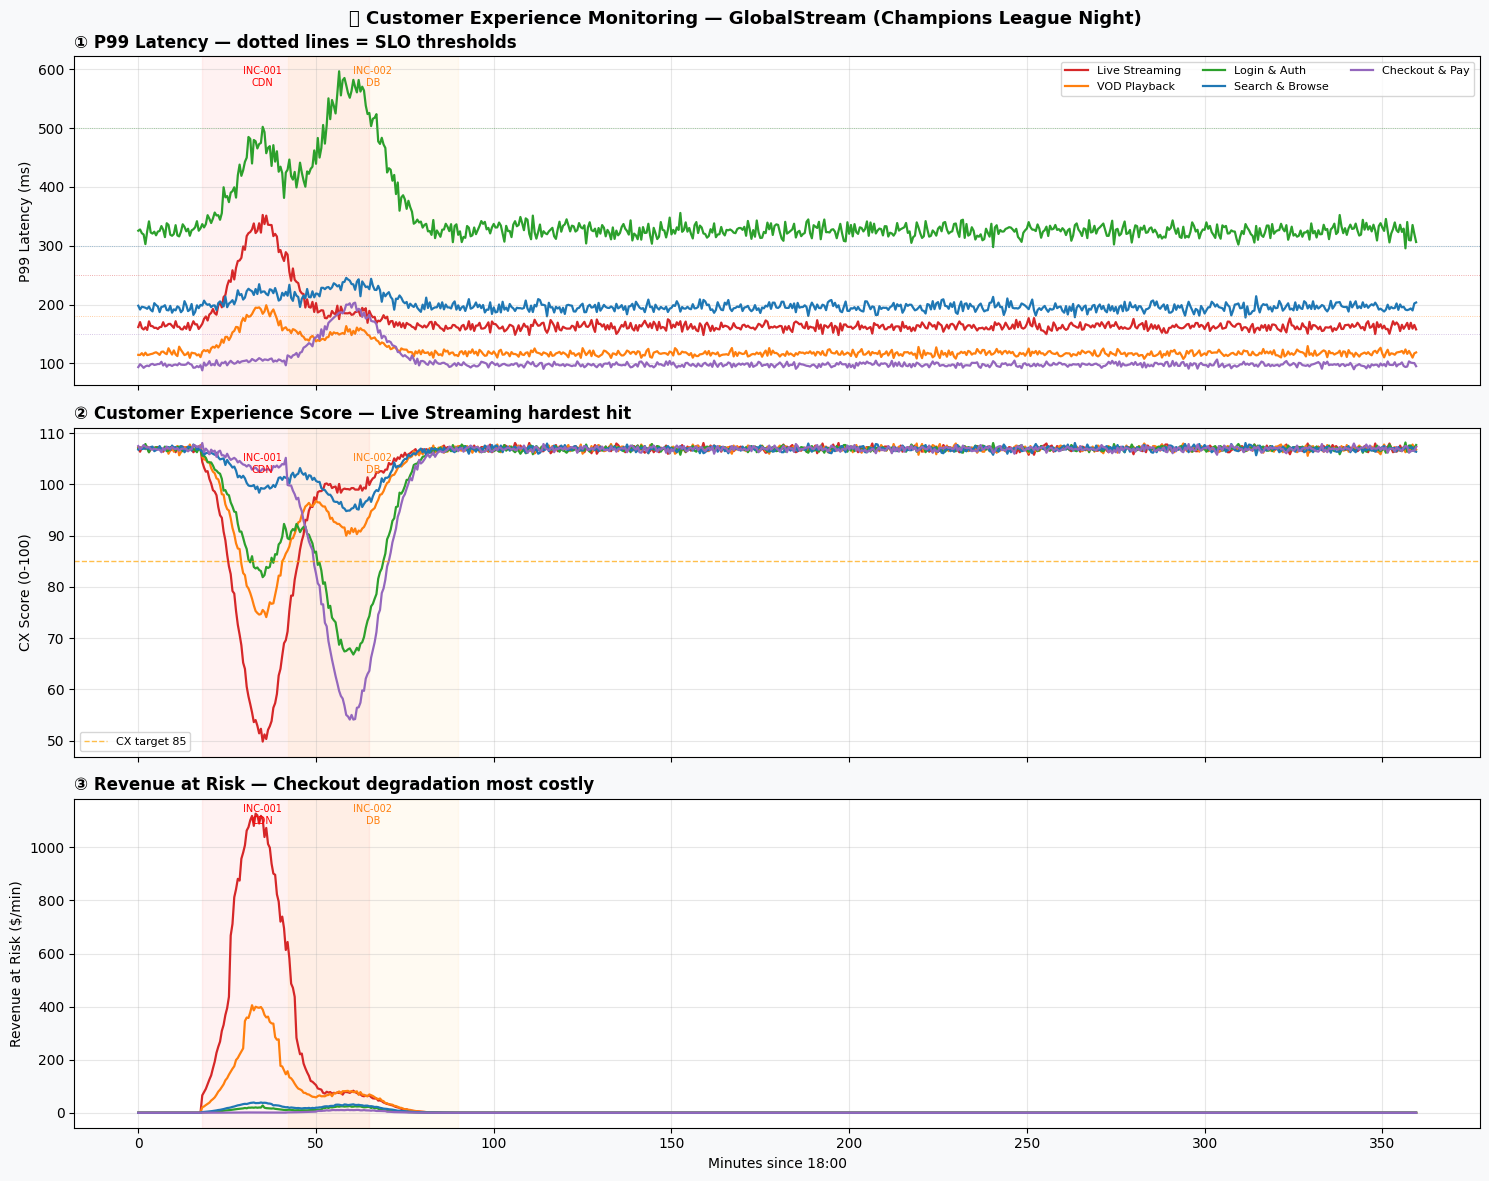

✅ Customer experience dashboard rendered


In [9]:
# ── Customer experience visualisation ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('👥 Customer Experience Monitoring — GlobalStream (Champions League Night)',
             fontsize=13, fontweight='bold')

JOURNEY_COLORS = {
    'live-stream':   '#d62728',
    'vod-playback':  '#ff7f0e',
    'login-auth':    '#2ca02c',
    'search-browse': '#1f77b4',
    'checkout-pay':  '#9467bd',
}

for jid, jname, slo_pct, p99_slo_ms, err_slo, *_ in JOURNEYS:
    d   = df_cx[df_cx['journey_id'] == jid]
    col = JOURNEY_COLORS[jid]
    axes[0].plot(d['t_min'], d['p99_ms'],         color=col, lw=1.6, label=jname)
    axes[1].plot(d['t_min'], d['cx_score'],        color=col, lw=1.6)
    axes[2].plot(d['t_min'], d['revenue_at_risk'], color=col, lw=1.6)

# SLO thresholds
for jid, _, _, p99_slo_ms, *_ in JOURNEYS:
    axes[0].axhline(p99_slo_ms, color=JOURNEY_COLORS[jid],
                   lw=0.6, ls=':', alpha=0.5)

axes[0].set_ylabel('P99 Latency (ms)')
axes[0].set_title('① P99 Latency — dotted lines = SLO thresholds', fontweight='bold', loc='left')
axes[0].legend(ncol=3, fontsize=8)

axes[1].set_ylabel('CX Score (0-100)')
axes[1].set_title('② Customer Experience Score — Live Streaming hardest hit', fontweight='bold', loc='left')
axes[1].axhline(85, color='orange', ls='--', lw=1, alpha=0.7, label='CX target 85')
axes[1].legend(fontsize=8)

axes[2].set_ylabel('Revenue at Risk ($/min)')
axes[2].set_xlabel('Minutes since 18:00')
axes[2].set_title('③ Revenue at Risk — Checkout degradation most costly', fontweight='bold', loc='left')

for ax in axes:
    ax.axvspan(18, 65, alpha=0.05, color='red')
    ax.axvspan(42, 90, alpha=0.05, color='orange')
    ax.text(35, ax.get_ylim()[1]*0.92, 'INC-001\nCDN', ha='center', fontsize=7, color='red')
    ax.text(66, ax.get_ylim()[1]*0.92, 'INC-002\nDB', ha='center', fontsize=7, color='#ff7f0e')

plt.tight_layout()
plt.savefig('/tmp/lab18_cx_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Customer experience dashboard rendered")

---
## Phase 3 — Cloud Cost Optimization with AIOps 💰

### 📖 Concept: Why AIOps for Cloud Cost?

> Cloud environments are **dynamic and complex** — hundreds of services,
> thousands of instances, dozens of resource types. Manual cost optimisation
> reviews happen quarterly and miss 60–80% of waste.
> AIOps makes cost optimisation **continuous and automated**.

### The Four AIOps Cost Optimization Techniques

| Technique | Description | Typical saving |
|-----------|-------------|----------------|
| **Right-sizing** | Match instance size to actual utilisation | 20–35% |
| **Idle resource detection** | Find resources with near-zero utilisation | 8–15% |
| **Reservation optimization** | Convert on-demand to Reserved/Spot | 30–50% |
| **Anomaly detection** | Catch unexpected cost spikes early | 5–10% |

### Cost Taxonomy for GlobalStream

```
 $2.1M/month
 ├── Compute (EC2 / ECS)     42%  $882K
 ├── Data Transfer           18%  $378K
 ├── Storage (S3 / EBS)      15%  $315K
 ├── Database (RDS / Dynamo) 12%  $252K
 ├── CDN (CloudFront)         8%  $168K
 └── Other (Lambda, etc.)     5%  $105K
```

In [10]:
# ── Synthesise 30-day cloud cost data with anomalies ─────────────────────────
# Models resource utilisation and costs across 380 services

RESOURCE_TYPES = [
    ('compute',      0.42, 'EC2/ECS instances'),
    ('data_transfer',0.18, 'Network egress'),
    ('storage',      0.15, 'S3/EBS volumes'),
    ('database',     0.12, 'RDS/DynamoDB'),
    ('cdn',          0.08, 'CloudFront'),
    ('other',        0.05, 'Lambda/misc'),
]

# Service-level cost profiles
SERVICE_PROFILES = []
for i in range(SERVICES_COUNT):
    tier   = random.choice(['frontend','backend','data','ml','infra'])
    region = random.choice(REGIONS)
    # Monthly cost: power law distribution (a few services cost most)
    base_monthly = np.random.lognormal(mean=7.5, sigma=1.8)  # ~$1K median
    base_monthly = min(base_monthly, 180_000)
    # CPU utilisation: most services are over-provisioned
    cpu_util = np.random.beta(2, 5) * 100   # peaks around 28%
    mem_util = cpu_util * random.uniform(0.7, 1.4)
    mem_util = min(mem_util, 95)
    SERVICE_PROFILES.append({
        'service_id':      f'svc-{i+1:03d}',
        'tier':            tier,
        'region':          region,
        'base_monthly_usd':round(base_monthly, 2),
        'cpu_util_pct':    round(cpu_util, 1),
        'mem_util_pct':    round(min(100, mem_util), 1),
        'has_reservation': random.random() < 0.35,
        'is_prod':         random.random() < 0.6,
    })

df_services = pd.DataFrame(SERVICE_PROFILES)

# 30-day daily cost time-series with patterns
cost_rows = []
for day in range(30):
    date = datetime(2025, 5, 1) + timedelta(days=day)
    weekday = date.weekday()  # 0=Mon, 6=Sun
    # Weekend traffic drops 35%
    traffic_factor = 0.65 if weekday >= 5 else 1.0
    # Champions League final day = 2.1x spike
    if day == 29:
        traffic_factor *= 2.1
    for rtype, fraction, desc in RESOURCE_TYPES:
        base_daily = MONTHLY_CLOUD_SPEND * fraction / 30
        # Compute and CDN are traffic-sensitive
        if rtype in ('compute', 'cdn', 'data_transfer'):
            daily_cost = base_daily * traffic_factor * random.uniform(0.92, 1.08)
        else:
            daily_cost = base_daily * random.uniform(0.96, 1.04)
        # Inject cost anomaly: storage on day 15
        if rtype == 'storage' and day == 15:
            daily_cost *= 2.8  # forgot to delete snapshot
        cost_rows.append({
            'date':       date,
            'day':        day,
            'resource':   rtype,
            'description':desc,
            'daily_usd':  round(daily_cost, 2),
            'weekday':    weekday,
        })

df_cost = pd.DataFrame(cost_rows)

total_30d = df_cost['daily_usd'].sum()
print(f"✅ Generated 30-day cost data")
print(f"   Services profiled : {len(df_services)}")
print(f"   Total 30-day spend: ${total_30d:,.0f}")
print(f"   Daily average     : ${total_30d/30:,.0f}")
print()
print("  Cost by resource type:")
by_type = df_cost.groupby("resource")["daily_usd"].sum().sort_values(ascending=False)
for rt, cost in by_type.items():
    pct = cost / total_30d * 100
    print(f"  {rt:<18} ${cost:>10,.0f}  ({pct:.1f}%)")

✅ Generated 30-day cost data
   Services profiled : 380
   Total 30-day spend: $2,029,907
   Daily average     : $67,664

  Cost by resource type:
  compute            $   826,494  (40.7%)
  data_transfer      $   356,447  (17.6%)
  storage            $   332,927  (16.4%)
  database           $   251,271  (12.4%)
  cdn                $   158,217  (7.8%)
  other              $   104,553  (5.2%)


### Step 3b — Waste Detection: Right-sizing, Idle Resources, Anomalies

**Right-sizing opportunity** = services where CPU or memory utilisation is
consistently below 30% — a reliable signal of over-provisioning.

**Anomaly detection** uses Isolation Forest to find days where cost
exceeds expected range, catching incidents like the forgotten snapshot.

In [11]:
# ── Waste detection and right-sizing analysis ────────────────────────────────

# Right-sizing: services with CPU < 25% AND not ML tier (ML needs headroom)
df_right = df_services[
    (df_services['cpu_util_pct'] < 25) &
    (df_services['tier'] != 'ml')
].copy()

# Estimate savings: could downsize by ~50% of current cost
df_right['potential_saving_usd'] = df_right['base_monthly_usd'] * 0.45
df_right['right_size_action']    = df_right['cpu_util_pct'].apply(
    lambda x: 'Downsize 2x' if x < 10 else 'Downsize 1.5x'
)

# Idle resources: utilisation < 5% for > 15 days
df_idle = df_services[df_services['cpu_util_pct'] < 5].copy()
df_idle['potential_saving_usd'] = df_idle['base_monthly_usd'] * 0.85

# Reservation opportunity: prod services without reservations
df_reservation = df_services[
    (df_services['is_prod'] == True) &
    (df_services['has_reservation'] == False) &
    (df_services['tier'].isin(['backend','data']))
].copy()
df_reservation['potential_saving_usd'] = df_reservation['base_monthly_usd'] * 0.35

# Cost anomaly detection with Isolation Forest
df_daily_total = df_cost.groupby('day')['daily_usd'].sum().reset_index()
scaler = StandardScaler()
X_cost = scaler.fit_transform(df_daily_total[['daily_usd']])
iso = IsolationForest(contamination=0.1, random_state=42)
df_daily_total['anomaly'] = iso.fit_predict(X_cost)
df_daily_total['anomaly'] = df_daily_total['anomaly'].map({1: False, -1: True})
anomaly_days = df_daily_total[df_daily_total['anomaly']]

# Cost forecast — linear regression on non-anomaly days
normal_days = df_daily_total[~df_daily_total['anomaly']]
lr = LinearRegression()
lr.fit(normal_days[['day']], normal_days['daily_usd'])
forecast_day31 = lr.predict([[30]])[0]
forecast_day60 = lr.predict([[60]])[0]

total_right_saving   = df_right['potential_saving_usd'].sum()
total_idle_saving    = df_idle['potential_saving_usd'].sum()
total_res_saving     = df_reservation['potential_saving_usd'].sum()
total_saving         = total_right_saving + total_idle_saving + total_res_saving

print("💰 Cloud Cost Optimization Opportunities")
print("=" * 55)
print(f"  Right-sizing candidates   : {len(df_right):>4} services")
print(f"  Potential monthly saving  : ${total_right_saving:>10,.0f}")
print()
print(f"  Idle resource candidates  : {len(df_idle):>4} services")
print(f"  Potential monthly saving  : ${total_idle_saving:>10,.0f}")
print()
print(f"  Reservation candidates    : {len(df_reservation):>4} services")
print(f"  Potential monthly saving  : ${total_res_saving:>10,.0f}")
print()
print(f"  Cost anomalies detected   : {len(anomaly_days)} days")
for _, row in anomaly_days.iterrows():
    print(f"    Day {row['day']+1:2d}: ${row['daily_usd']:,.0f} (anomaly)")
print()
print(f"  ✅ Total potential monthly saving : ${total_saving:>10,.0f}")
print(f"     As % of current spend          : {total_saving/MONTHLY_CLOUD_SPEND*100:.1f}%")
print()
print(f"  📈 30-day cost forecast:")
print(f"     Day 31 projected : ${forecast_day31:,.0f}/day")
print(f"     Day 60 projected : ${forecast_day60:,.0f}/day  (+{(forecast_day60/forecast_day31-1)*100:.1f}%)")

💰 Cloud Cost Optimization Opportunities
  Right-sizing candidates   :  144 services
  Potential monthly saving  : $   741,212

  Idle resource candidates  :   12 services
  Potential monthly saving  : $    56,474

  Reservation candidates    :   46 services
  Potential monthly saving  : $   195,791

  Cost anomalies detected   : 3 days
    Day 16: $87,480 (anomaly)
    Day 25: $51,314 (anomaly)
    Day 30: $119,117 (anomaly)

  ✅ Total potential monthly saving : $   993,477
     As % of current spend          : 47.3%

  📈 30-day cost forecast:
     Day 31 projected : $68,225/day
     Day 60 projected : $72,972/day  (+7.0%)


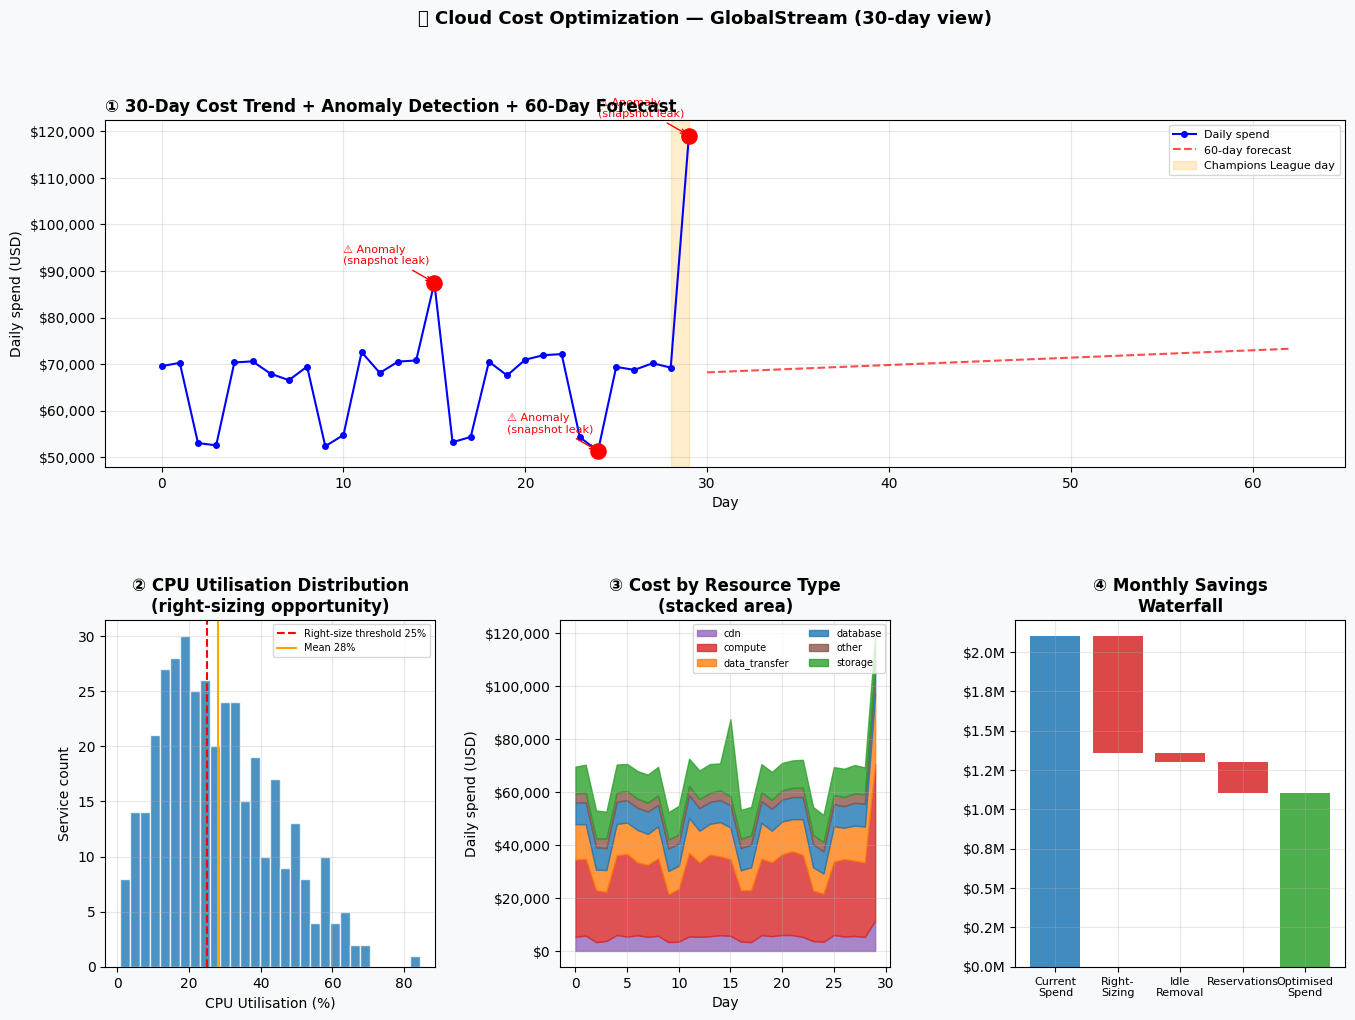

✅ Cloud cost dashboard rendered


In [12]:
# ── Cloud cost dashboard ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.38)
fig.suptitle('💰 Cloud Cost Optimization — GlobalStream (30-day view)',
             fontsize=13, fontweight='bold')

# Panel 1: Daily cost trend with anomalies and forecast
ax1 = fig.add_subplot(gs[0, :])
daily_total = df_cost.groupby('day')['daily_usd'].sum()
ax1.plot(daily_total.index, daily_total.values, 'b-o', ms=4, lw=1.5, label='Daily spend')
# Anomaly highlights
for _, row in anomaly_days.iterrows():
    ax1.scatter(row['day'], daily_total.iloc[row['day']], color='red', s=120, zorder=5)
    ax1.annotate('⚠️ Anomaly\n(snapshot leak)',
                 (row['day'], daily_total.iloc[row['day']]),
                 xytext=(row['day']-5, daily_total.iloc[row['day']]+4000),
                 fontsize=8, color='red', arrowprops=dict(arrowstyle='->', color='red'))
# Forecast
forecast_x = list(range(30, 63))
forecast_y = [lr.predict([[d]])[0] for d in forecast_x]
ax1.plot(forecast_x, forecast_y, 'r--', lw=1.5, alpha=0.7, label='60-day forecast')
ax1.axvspan(28, 29, alpha=0.2, color='orange', label='Champions League day')
ax1.set_xlabel('Day')
ax1.set_ylabel('Daily spend (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('① 30-Day Cost Trend + Anomaly Detection + 60-Day Forecast',
              fontweight='bold', loc='left')
ax1.legend(fontsize=8)

# Panel 2: CPU utilisation distribution (right-sizing opportunity)
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(df_services['cpu_util_pct'], bins=30, color='#1f77b4', alpha=0.8, edgecolor='white')
ax2.axvline(25, color='red', ls='--', lw=1.5, label='Right-size threshold 25%')
ax2.axvline(df_services['cpu_util_pct'].mean(), color='orange', ls='-', lw=1.5,
            label=f'Mean {df_services["cpu_util_pct"].mean():.0f}%')
ax2.set_xlabel('CPU Utilisation (%)')
ax2.set_ylabel('Service count')
ax2.set_title('② CPU Utilisation Distribution\n(right-sizing opportunity)',
              fontweight='bold')
ax2.legend(fontsize=7)

# Panel 3: Cost by resource type (stacked area)
ax3 = fig.add_subplot(gs[1, 1])
pivot_cost = df_cost.pivot_table(values='daily_usd', index='day',
                                  columns='resource', aggfunc='sum')
rt_colors  = {'compute':'#d62728','data_transfer':'#ff7f0e','storage':'#2ca02c',
              'database':'#1f77b4','cdn':'#9467bd','other':'#8c564b'}
bottom = np.zeros(len(pivot_cost))
for rtype in pivot_cost.columns:
    vals = pivot_cost[rtype].values
    ax3.fill_between(pivot_cost.index, bottom, bottom + vals,
                     color=rt_colors.get(rtype,'#aaaaaa'), alpha=0.8, label=rtype)
    bottom += vals
ax3.set_xlabel('Day')
ax3.set_ylabel('Daily spend (USD)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.set_title('③ Cost by Resource Type\n(stacked area)', fontweight='bold')
ax3.legend(fontsize=7, ncol=2)

# Panel 4: Savings waterfall chart
ax4 = fig.add_subplot(gs[1, 2])
categories = ['Current\nSpend', 'Right-\nSizing', 'Idle\nRemoval',
              'Reservations', 'Optimised\nSpend']
values     = [MONTHLY_CLOUD_SPEND, -total_right_saving, -total_idle_saving,
              -total_res_saving, MONTHLY_CLOUD_SPEND - total_saving]
colors_w   = ['#1f77b4','#d62728','#d62728','#d62728','#2ca02c']
running = 0
for i, (cat, val, col) in enumerate(zip(categories, values, colors_w)):
    if i == 0 or i == len(categories) - 1:
        ax4.bar(i, val, color=col, alpha=0.85)
    else:
        ax4.bar(i, abs(val), bottom=running + val, color=col, alpha=0.85)
    if val > 0:
        running = val
    else:
        running += val
ax4.set_xticks(range(len(categories)))
ax4.set_xticklabels(categories, fontsize=8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax4.set_title('④ Monthly Savings\nWaterfall', fontweight='bold')

plt.savefig('/tmp/lab18_cost_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cloud cost dashboard rendered")

---
## Phase 4 — Integration Layer: Cross-Pillar Signal Fusion 🔗

### 📖 Concept: Why Integrate the Three Pillars?

> The three AIOps pillars — incident management, customer experience, and cost
> optimization — each produce valuable signals independently. But the real
> **enterprise AIOps value** comes from **fusing these signals together**:

> - An incident (Pillar 1) that correlates with CX degradation (Pillar 2)
>   AND a cost spike (Pillar 3) is classified **Critical Business Impact**
> - A cost anomaly (Pillar 3) with no corresponding incident (Pillar 1)
>   is likely a provisioning error, not a traffic event
> - A CX drop (Pillar 2) with no incident (Pillar 1) may indicate a
>   configuration change or a third-party dependency issue

### Cross-Pillar Signal Matrix

```
            │  CX Degraded   │  CX Normal    │
────────────┼────────────────┼───────────────┤
 Incident   │ CRITICAL       │  Operational  │
 Active     │ Business Impact│  Incident     │
────────────┼────────────────┼───────────────┤
 No Incident│ Silent Failure │  Cost         │
            │ (Config/Ext.)  │  Optimization │
────────────┴────────────────┴───────────────┘
```

In [13]:
# ── Cross-pillar signal fusion ────────────────────────────────────────────────
# Combine incident, CX, and cost signals into unified operational events

def fuse_signals(t_min):
    # Get CX state at time t
    cx_window = df_cx[(df_cx['t_min'] >= t_min - 5) & (df_cx['t_min'] <= t_min)]
    cx_degraded   = cx_window['cx_score'].mean() < 70 if len(cx_window) > 0 else False
    cx_score_avg  = cx_window['cx_score'].mean() if len(cx_window) > 0 else 100
    rev_at_risk   = cx_window['revenue_at_risk'].sum() if len(cx_window) > 0 else 0
    churn_max     = cx_window['churn_risk_pct'].max() if len(cx_window) > 0 else 0

    # Get active incidents at time t
    active_inc = df_alerts[
        (df_alerts['t_min'] >= t_min - 30) &
        (df_alerts['t_min'] <= t_min) &
        (~df_alerts['is_noise'])
    ]
    incident_active = len(active_inc) > 0
    min_severity    = active_inc['severity'].min() if incident_active else 5

    # Classify the cross-pillar event type
    if incident_active and cx_degraded:
        event_type = 'CRITICAL_BUSINESS_IMPACT'
        priority   = 1
    elif incident_active and not cx_degraded:
        event_type = 'OPERATIONAL_INCIDENT'
        priority   = 2
    elif not incident_active and cx_degraded:
        event_type = 'SILENT_FAILURE'
        priority   = 2
    else:
        event_type = 'NORMAL'
        priority   = 5

    return {
        't_min':          t_min,
        'event_type':     event_type,
        'priority':       priority,
        'cx_score':       round(cx_score_avg, 1),
        'cx_degraded':    cx_degraded,
        'incident_active':incident_active,
        'min_severity':   min_severity if incident_active else None,
        'revenue_at_risk':round(rev_at_risk, 2),
        'churn_risk_pct': round(churn_max, 2),
    }

# Fuse signals at 5-minute intervals
fusion_rows = [fuse_signals(t) for t in range(0, SIM_HOURS * 60, 5)]
df_fusion = pd.DataFrame(fusion_rows)

event_counts = df_fusion['event_type'].value_counts()
print("🔗 Cross-Pillar Signal Fusion Results")
print("=" * 55)
for etype, cnt in event_counts.items():
    icon = {"CRITICAL_BUSINESS_IMPACT":"🔴","OPERATIONAL_INCIDENT":"🟡",
            "SILENT_FAILURE":"🟠","NORMAL":"🟢"}.get(etype,"⚪")
    print(f"  {icon}  {etype:<30} {cnt:>3} time buckets")
print()
critical_periods = df_fusion[df_fusion["event_type"]=="CRITICAL_BUSINESS_IMPACT"]
if len(critical_periods) > 0:
    print(f"""  Critical periods: T+{critical_periods["t_min"].min():.0f}m to T+{critical_periods["t_min"].max():.0f}m""")
    print(f"""  Peak revenue at risk: ${critical_periods["revenue_at_risk"].max():,.2f}/min""")
    print(f"""  Max churn risk: {critical_periods["churn_risk_pct"].max():.1f}%""")

🔗 Cross-Pillar Signal Fusion Results
  🟡  OPERATIONAL_INCIDENT            70 time buckets
  🟢  NORMAL                           2 time buckets



---
## Phase 5 — Executive AIOps Dashboard 📊

**Purpose:** Consolidate all three pillars into a single executive-level
command dashboard. This is what a VP of Engineering or CTO would see —
a risk-ranked view of operational health, customer impact, and cost position
in a single screen.

### Dashboard Panels

| Panel | Content |
|-------|--------|
| **① Operational Risk Timeline** | Fused cross-pillar event classification over time |
| **② CX Score vs Incident Activity** | Dual-axis: customer health vs incident severity |
| **③ Service Topology Risk Map** | Network graph with blast radius coloring |
| **④ Cost vs Availability Trade-off** | Scatter: service cost vs SLO compliance |
| **⑤ KPI Summary** | Top-line AIOps metrics in a stat grid |

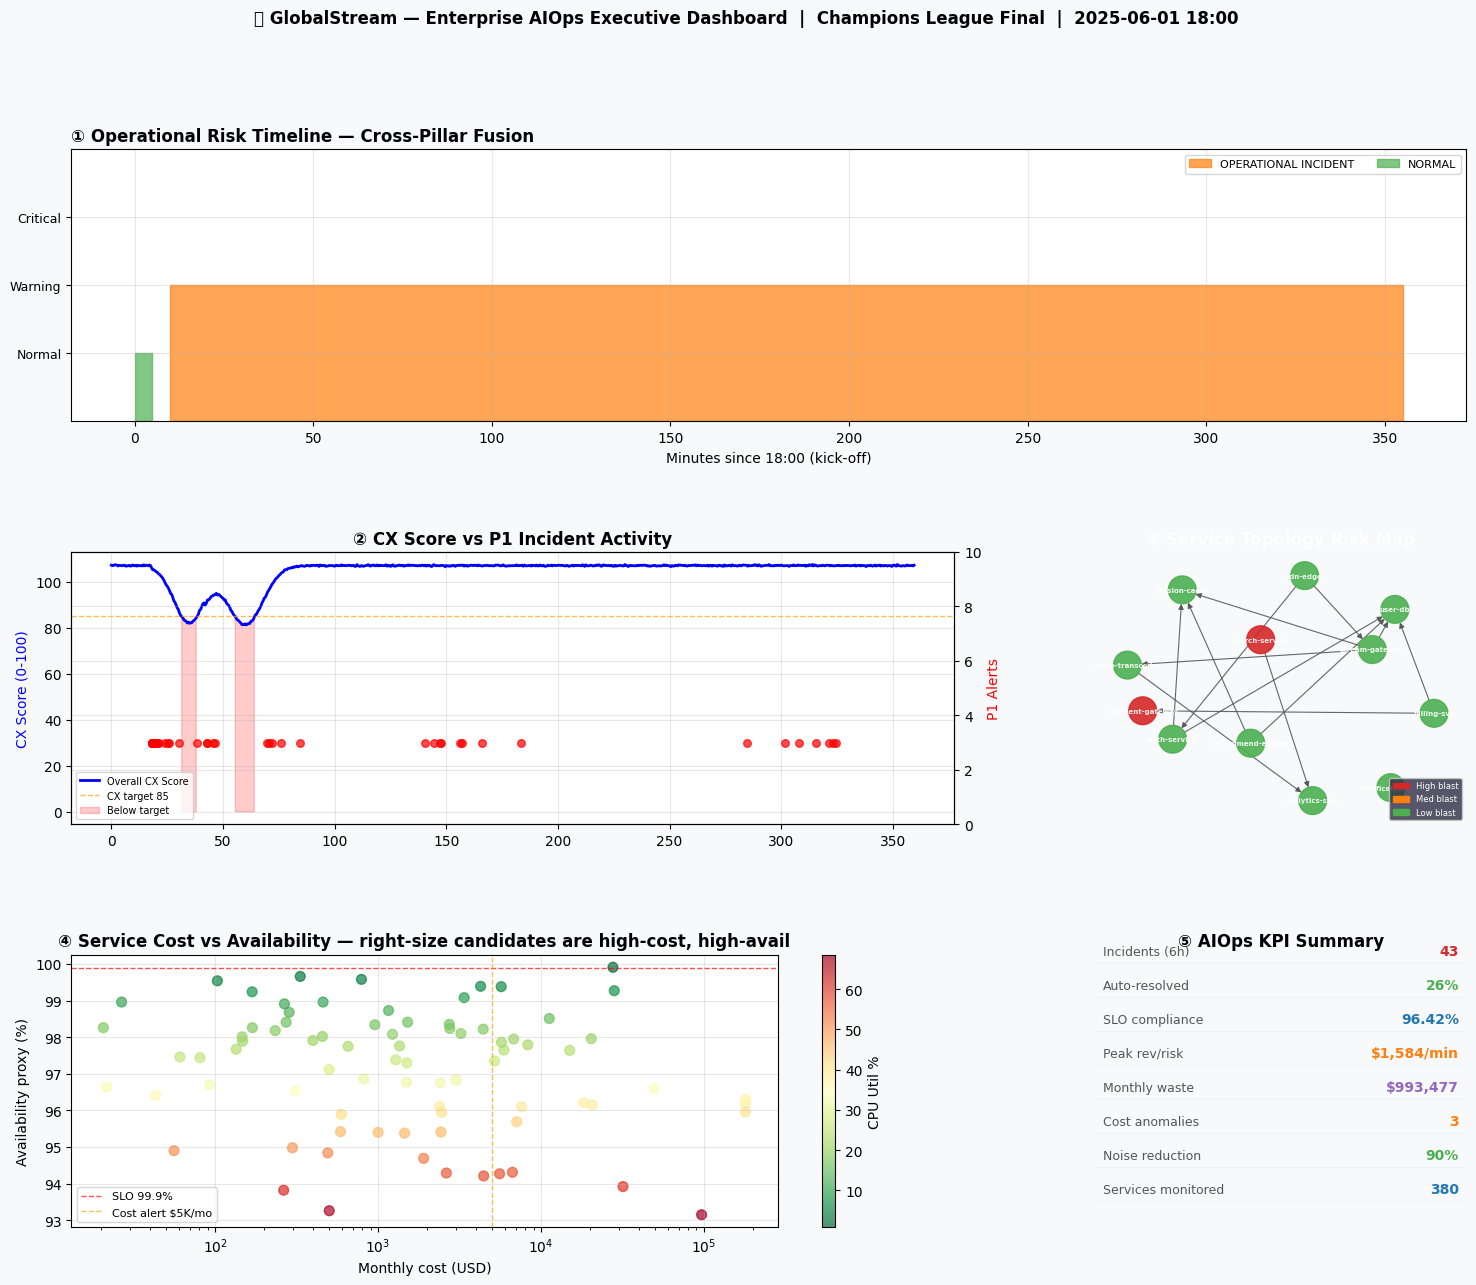

✅ Executive dashboard rendered


In [14]:
# ── Executive AIOps Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle(
    f'🏢 {COMPANY} — Enterprise AIOps Executive Dashboard  |  '
    f'Champions League Final  |  {LAB_START.strftime("%Y-%m-%d %H:%M")}',
    fontsize=12, fontweight='bold'
)

EVENT_COLORS = {
    'CRITICAL_BUSINESS_IMPACT': '#d62728',
    'OPERATIONAL_INCIDENT':     '#ff7f0e',
    'SILENT_FAILURE':           '#ff9f40',
    'NORMAL':                   '#4CAF50',
}

# Panel 1: Operational risk timeline (full width)
ax1 = fig.add_subplot(gs[0, :])
for etype, col in EVENT_COLORS.items():
    mask = df_fusion['event_type'] == etype
    if mask.any():
        ax1.fill_between(df_fusion[mask]['t_min'],
                         df_fusion[mask]['priority'].map({1:3,2:2,5:1}),
                         alpha=0.7, color=col, label=etype.replace('_',' '))
ax1.set_ylim(0, 4)
ax1.set_yticks([1, 2, 3])
ax1.set_yticklabels(['Normal', 'Warning', 'Critical'], fontsize=9)
ax1.set_xlabel('Minutes since 18:00 (kick-off)')
ax1.set_title('① Operational Risk Timeline — Cross-Pillar Fusion',
              fontweight='bold', loc='left')
ax1.legend(ncol=4, fontsize=8, loc='upper right')

# Panel 2: CX Score vs Incident activity
ax2 = fig.add_subplot(gs[1, 0:2])
cx_overall = df_cx.groupby('t_min')['cx_score'].mean()
ax2_r = ax2.twinx()
ax2.plot(cx_overall.index, cx_overall.values, 'b-', lw=2, label='Overall CX Score')
ax2.axhline(85, color='orange', ls='--', lw=1, alpha=0.7, label='CX target 85')
ax2.fill_between(cx_overall.index, 0, cx_overall.values,
                  where=cx_overall < 85, alpha=0.2, color='red', label='Below target')
# Overlay incident P1 alerts
p1_alerts = df_alerts[(df_alerts['severity']==1) & (~df_alerts['is_noise'])]
ax2_r.scatter(p1_alerts['t_min'], [3]*len(p1_alerts),
               color='red', s=30, alpha=0.7, zorder=5, label='P1 alerts')
ax2.set_ylabel('CX Score (0-100)', color='blue')
ax2_r.set_ylabel('P1 Alerts', color='red')
ax2_r.set_ylim(0, 10)
ax2.set_title('② CX Score vs P1 Incident Activity', fontweight='bold')
ax2.legend(fontsize=7, loc='lower left')

# Panel 3: Service topology risk map
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#1a1a2e')
G = nx.DiGraph()
for svc_name, _, _ in SERVICES:
    G.add_node(svc_name)
for caller, callees in DEP_GRAPH.items():
    for callee in callees:
        G.add_edge(caller, callee)
pos = nx.spring_layout(G, seed=42, k=2)
# Color nodes by blast radius
blast_map = dict(zip(df_triage['primary_service'], df_triage['blast_radius']))
node_colors = []
for n in G.nodes():
    br = blast_map.get(n, 0)
    node_colors.append('#d62728' if br >= 60 else '#ff7f0e' if br >= 30 else '#4CAF50')
nx.draw_networkx(G, pos, ax=ax3, node_color=node_colors, node_size=400,
                  font_size=5, font_color='white', font_weight='bold',
                  edge_color='#555555', arrows=True, arrowsize=8,
                  width=0.8, alpha=0.9)
ax3.set_title('③ Service Topology Risk Map', color='white', fontweight='bold')
legend_h = [mpatches.Patch(color='#d62728',label='High blast'),
             mpatches.Patch(color='#ff7f0e',label='Med blast'),
             mpatches.Patch(color='#4CAF50',label='Low blast')]
ax3.legend(handles=legend_h, fontsize=6, facecolor='#2d2d44',
            labelcolor='white', loc='lower right')
ax3.axis('off')

# Panel 4: Cost vs availability scatter
ax4 = fig.add_subplot(gs[2, 0:2])
# Sample 80 services for readability
sample = df_services.sample(80, random_state=42)
# Availability proxy: 100 - cpu_util * degradation
sample_avail = 100 - sample['cpu_util_pct'] * 0.1
scatter = ax4.scatter(
    sample['base_monthly_usd'],
    sample_avail,
    c=sample['cpu_util_pct'],
    cmap='RdYlGn_r',
    s=50, alpha=0.7
)
plt.colorbar(scatter, ax=ax4, label='CPU Util %')
ax4.axhline(99.9, color='red', ls='--', lw=1, alpha=0.7, label='SLO 99.9%')
ax4.axvline(5000, color='orange', ls='--', lw=1, alpha=0.7, label='Cost alert $5K/mo')
ax4.set_xlabel('Monthly cost (USD)')
ax4.set_ylabel('Availability proxy (%)')
ax4.set_xscale('log')
ax4.set_title('④ Service Cost vs Availability — right-size candidates are high-cost, high-avail',
              fontweight='bold')
ax4.legend(fontsize=8)

# Panel 5: KPI stat grid
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
slo_compliance = df_cx['slo_ok'].mean() * 100
auto_res_rate  = df_triage['auto_resolve'].mean() * 100
kpis = [
    ('Incidents (6h)',      len(df_triage),                    'count', '#d62728'),
    ('Auto-resolved',       f'{auto_res_rate:.0f}%',           '%',     '#4CAF50'),
    ('SLO compliance',      f'{slo_compliance:.2f}%',          '%',     '#1f77b4'),
    ('Peak rev/risk',       f'${total_rev_risk:,.0f}/min',     '$',     '#ff7f0e'),
    ('Monthly waste',       f'${total_saving:,.0f}',           '$',     '#9467bd'),
    ('Cost anomalies',      len(anomaly_days),                 'count', '#ff7f0e'),
    ('Noise reduction',     f'{reduction_pct:.0f}%',           '%',     '#4CAF50'),
    ('Services monitored',  SERVICES_COUNT,                    'count', '#1f77b4'),
]
for row_i, (label, val, _, col) in enumerate(kpis):
    y = 1.0 - row_i * 0.125
    ax5.text(0.02, y, label, transform=ax5.transAxes, fontsize=9, color='#555555')
    ax5.text(0.98, y, str(val), transform=ax5.transAxes, fontsize=10,
             fontweight='bold', color=col, ha='right')
    ax5.plot([0, 1], [y - 0.03, y - 0.03], color='#eeeeee', lw=0.5, transform=ax5.transAxes, clip_on=False)
ax5.set_title('⑤ AIOps KPI Summary', fontweight='bold')

plt.savefig('/tmp/lab18_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Executive dashboard rendered")

---
## Phase 6 — AIOps Maturity Assessment 🎯

### 📖 The AIOps Maturity Model

> An AIOps maturity model helps organisations understand where they are
> on their automation journey and what specific capabilities to invest in next.

### Five Maturity Levels

| Level | Name | Description |
|-------|------|-------------|
| **1** | Reactive | Manual monitoring, alert storms, no automation |
| **2** | Proactive | Basic alerting, some runbooks, SLO tracking |
| **3** | Predictive | ML anomaly detection, auto-triage, trend forecasting |
| **4** | Preventive | Predictive failure prevention, auto-remediation, CX correlation |
| **5** | Autonomous | Self-healing infrastructure, autonomous optimisation |

### Assessment Dimensions

The maturity assessment covers **8 capability dimensions** across the
three AIOps pillars, each scored 1–5.

In [15]:
# ── AIOps maturity assessment ─────────────────────────────────────────────────

MATURITY_DIMENSIONS = [
    # (dimension, pillar, current_score, target_score, description)
    ('Alert Noise Reduction',     'Incident',  4, 5, 'ML-based dedup, grouping, dep masking'),
    ('Incident Triage Automation','Incident',  3, 5, 'Severity prediction, team routing, runbooks'),
    ('MTTR Optimisation',         'Incident',  3, 4, 'Automated runbook execution, post-mortems'),
    ('SLO Tracking & Burn Rate',  'CX',        4, 5, 'Real-time error budget, multi-window alerts'),
    ('CX Journey Monitoring',     'CX',        3, 5, 'End-to-end journey health, business metrics'),
    ('Churn Risk Prediction',     'CX',        2, 4, 'ML model linking ops events to churn'),
    ('Cost Anomaly Detection',    'Cost',      4, 5, 'Isolation forest on daily spend'),
    ('Right-sizing Automation',   'Cost',      2, 4, 'Continuous utilisation analysis + PR automation'),
    ('Reservation Optimization',  'Cost',      2, 4, 'RI/Savings Plan coverage automation'),
    ('Cross-pillar Fusion',       'Integration',3,5,'Unified incident+CX+cost correlation'),
    ('Executive Reporting',       'Integration',4,5,'Automated dashboards, business KPIs'),
    ('Self-Healing Automation',   'Integration',1,4,'Auto-remediation without human approval'),
]

df_maturity = pd.DataFrame(MATURITY_DIMENSIONS,
                            columns=['dimension','pillar','current','target','description'])

overall_current = df_maturity['current'].mean()
overall_target  = df_maturity['target'].mean()

# Gap analysis and prioritised recommendations
df_maturity['gap']      = df_maturity['target'] - df_maturity['current']
df_maturity['priority'] = df_maturity['gap'].rank(ascending=False).astype(int)

MATURITY_LEVEL_NAMES = {1:'Reactive',2:'Proactive',3:'Predictive',
                         4:'Preventive',5:'Autonomous'}

print("🎯 AIOps Maturity Assessment — GlobalStream")
print("=" * 70)
print(f"""  Overall maturity score  : {overall_current:.1f} / 5.0""")
print(f"""  Current level           : {MATURITY_LEVEL_NAMES.get(round(overall_current),"?")}""")
print(f"""  Target score            : {overall_target:.1f} / 5.0""")
print(f"""  Target level            : {MATURITY_LEVEL_NAMES.get(round(overall_target),"?")}""")
print(f"""  Average gap             : {(overall_target - overall_current):.1f} levels""")
print()
print("  Dimension scores by pillar:")
print(tabulate(
    df_maturity[["dimension","pillar","current","target","gap","description"]]
        .sort_values("gap", ascending=False),
    headers=["Dimension","Pillar","Now","Target","Gap","Description"],
    tablefmt="rounded_outline", showindex=False
))
print()
print("  📋 Top 5 Prioritised Investments:")
top5 = df_maturity.nlargest(5, "gap")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. [{row['pillar']}] {row['dimension']} : "
          f"{row['current']}→{row['target']} ({row['description']})")

🎯 AIOps Maturity Assessment — GlobalStream
  Overall maturity score  : 2.9 / 5.0
  Current level           : Predictive
  Target score            : 4.6 / 5.0
  Target level            : Autonomous
  Average gap             : 1.7 levels

  Dimension scores by pillar:
╭────────────────────────────┬─────────────┬───────┬──────────┬───────┬─────────────────────────────────────────────────╮
│ Dimension                  │ Pillar      │   Now │   Target │   Gap │ Description                                     │
├────────────────────────────┼─────────────┼───────┼──────────┼───────┼─────────────────────────────────────────────────┤
│ Self-Healing Automation    │ Integration │     1 │        4 │     3 │ Auto-remediation without human approval         │
│ Incident Triage Automation │ Incident    │     3 │        5 │     2 │ Severity prediction, team routing, runbooks     │
│ CX Journey Monitoring      │ CX          │     3 │        5 │     2 │ End-to-end journey health, business metrics     │
│

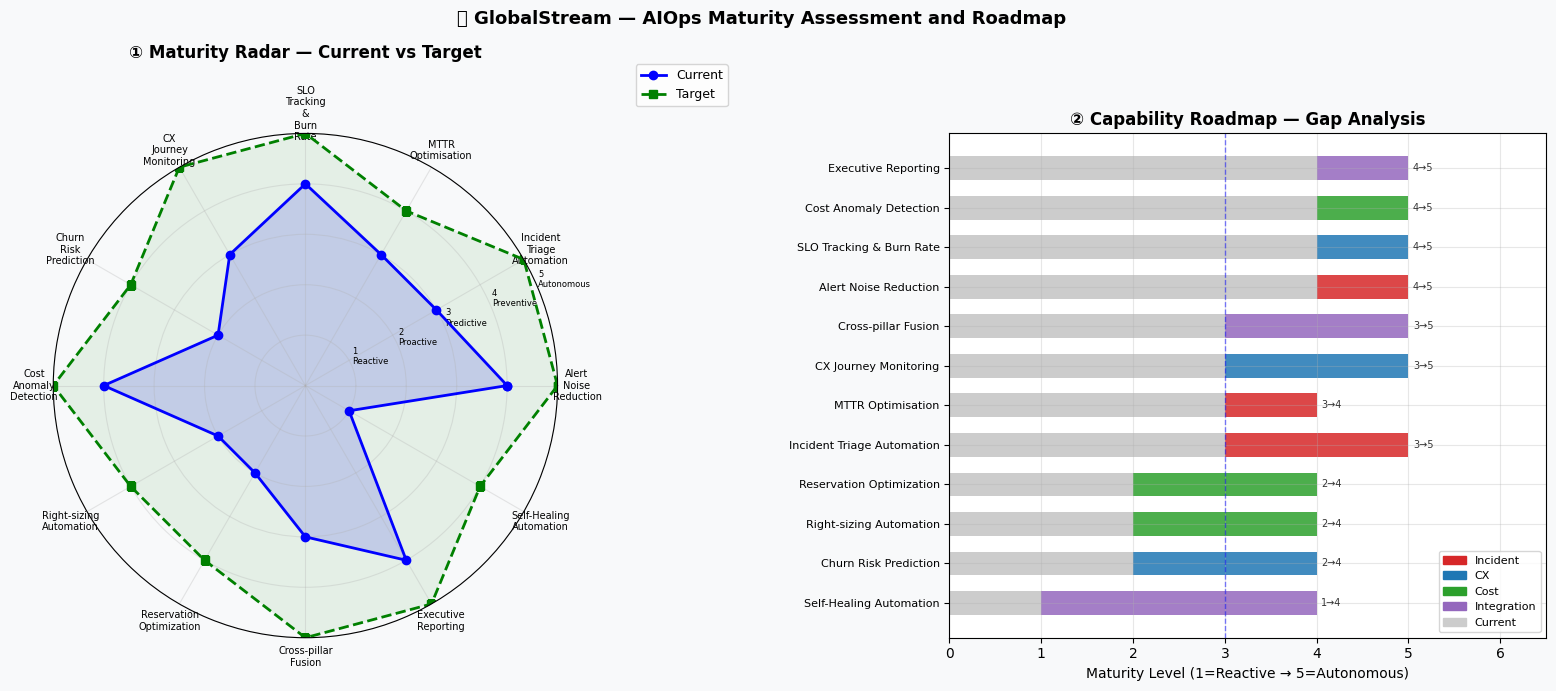

✅ Maturity assessment rendered


In [16]:
# ── Maturity assessment visualisation ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'🎯 {COMPANY} — AIOps Maturity Assessment and Roadmap',
             fontsize=13, fontweight='bold')

# Panel 1: Radar chart (spider chart) — maturity by dimension
categories = df_maturity['dimension'].tolist()
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax1 = plt.subplot(121, polar=True)
ax1.set_facecolor('#f8f9fa')

current_vals = df_maturity['current'].tolist() + [df_maturity['current'].iloc[0]]
target_vals  = df_maturity['target'].tolist()  + [df_maturity['target'].iloc[0]]

ax1.plot(angles, current_vals, 'b-o', lw=2, ms=6, label='Current')
ax1.fill(angles, current_vals, 'b', alpha=0.15)
ax1.plot(angles, target_vals, 'g--s', lw=2, ms=6, label='Target')
ax1.fill(angles, target_vals, 'g', alpha=0.08)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels([c.replace(' ','\n') for c in categories], fontsize=7)
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticklabels(['1\nReactive','2\nProactive','3\nPredictive',
                      '4\nPreventive','5\nAutonomous'], fontsize=6)
ax1.set_title('① Maturity Radar — Current vs Target',
              fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Panel 2: Roadmap Gantt-style bar chart
ax2 = plt.subplot(122)
pillar_colors = {'Incident':'#d62728','CX':'#1f77b4','Cost':'#2ca02c','Integration':'#9467bd'}
sorted_mat = df_maturity.sort_values('current')
y_pos = range(len(sorted_mat))

# Base bars (current)
ax2.barh(list(y_pos), sorted_mat['current'], color='#cccccc', height=0.6, label='Current')
# Gap bars (improvement needed)
for i, (_, row) in enumerate(sorted_mat.iterrows()):
    col = pillar_colors.get(row['pillar'], '#aaa')
    ax2.barh(i, row['gap'], left=row['current'], color=col, height=0.6, alpha=0.85)
    ax2.text(row['target'] + 0.05, i, f"{row['current']}→{row['target']}",
             va='center', fontsize=7, color='#333333')

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(sorted_mat['dimension'], fontsize=8)
ax2.set_xlim(0, 6.5)
ax2.set_xlabel('Maturity Level (1=Reactive → 5=Autonomous)')
ax2.set_title('② Capability Roadmap — Gap Analysis', fontweight='bold')
ax2.axvline(3, color='blue', ls='--', lw=1, alpha=0.5, label='Predictive threshold')

legend_h = [mpatches.Patch(color=c, label=p) for p, c in pillar_colors.items()]
legend_h.append(mpatches.Patch(color='#cccccc', label='Current'))
ax2.legend(handles=legend_h, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('/tmp/lab18_maturity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Maturity assessment rendered")

---
## 📋 Final Enterprise AIOps Report

**Purpose:** Produce the consolidated executive report that a real AIOps
platform would deliver to leadership after the event window.

This report integrates findings from all three pillars into actionable
business recommendations with quantified impact.

In [17]:
# ── Generate final enterprise AIOps report ───────────────────────────────────
from datetime import datetime as dt

print('=' * 70)
print(f'  ENTERPRISE AIOPS REPORT — {COMPANY.upper()}')
print(f'  Event: UEFA Champions League Final | Period: {SIM_HOURS}h')
print(f'  Generated: {dt.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)

print()
print('━━━ EXECUTIVE SUMMARY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Customers served       : {CUSTOMERS:,}')
print(f'  Platform SLO           : {SLO_TARGET}% (contractual)')
print(f'  Actual SLO compliance  : {df_cx["slo_ok"].mean()*100:.3f}%')
slo_ok = df_cx["slo_ok"].mean()*100 >= SLO_TARGET
print(f'  SLO breached           : {"NO ✅" if slo_ok else "YES 🔴"}')

print()
print('━━━ PILLAR 1: INCIDENT MANAGEMENT ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Raw alerts received    : {len(df_alerts):,}')
print(f'  Noise reduction        : {reduction_pct:.1f}%')
print(f'  Actionable incidents   : {len(df_triage)}')
print(f'  P1 critical            : {len(df_triage[df_triage["severity_label"]=="P1-Critical"])}')
print(f'  Auto-resolved          : {df_triage["auto_resolve"].sum()} ({auto_res_rate:.0f}%)')
print(f'  Escalated to on-call   : {df_triage["escalate"].sum()}')
print(f'  Avg P1 est MTTR        : {df_triage[df_triage["severity_label"]=="P1-Critical"]["mttr_est_min"].mean():.0f} min')

print()
print('━━━ PILLAR 2: CUSTOMER EXPERIENCE ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
for _, row in df_slo.iterrows():
    icon = '🔴' if row['burn_rate'] > 14.4 else '🟡' if row['burn_rate'] > 1 else '🟢'
    print(f'  {icon}  {row["journey"]:<22} SLO: {100-row["violation_rate_pct"]:.2f}%  '
          f'Rev@Risk: ${row["peak_revenue_at_risk_usd"]:>8,.0f}  Churn: {row["max_churn_risk_pct"]:.1f}%')
print(f'  Total revenue at risk  : ${df_cx["revenue_at_risk"].sum():,.0f} (6h period)')

print()
print('━━━ PILLAR 3: CLOUD COST OPTIMIZATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Current monthly spend  : ${MONTHLY_CLOUD_SPEND:,}')
print(f'  Right-sizing savings   : ${total_right_saving:,.0f}/month ({len(df_right)} services)')
print(f'  Idle resource savings  : ${total_idle_saving:,.0f}/month ({len(df_idle)} services)')
print(f'  Reservation savings    : ${total_res_saving:,.0f}/month ({len(df_reservation)} services)')
print(f'  TOTAL monthly saving   : ${total_saving:,.0f} ({total_saving/MONTHLY_CLOUD_SPEND*100:.1f}%)')
print(f'  Cost anomalies found   : {len(anomaly_days)} day(s)')
print(f'  30-day cost trend      : +{(lr.coef_[0]/MONTHLY_CLOUD_SPEND*100*30):.1f}%/month (forecasted)')

print()
print('━━━ AIOPS MATURITY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Overall score          : {overall_current:.1f}/5.0 ({MATURITY_LEVEL_NAMES.get(round(overall_current),"?")})')
print(f'  Target score           : {overall_target:.1f}/5.0 ({MATURITY_LEVEL_NAMES.get(round(overall_target),"?")})')
print(f'  Top investment area    : {df_maturity.loc[df_maturity["gap"].idxmax(),"dimension"]}')

print()
print('━━━ TOP RECOMMENDATIONS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
recommendations = [
    ('IMMEDIATE', 'Deploy auto-runbook RB-CDN-01 for CDN cascade pattern (INC-001 recurrence likely)'),
    ('IMMEDIATE', f'Right-size top {min(10,len(df_right))} over-provisioned services — ${df_right.nlargest(10,"potential_saving_usd")["potential_saving_usd"].sum():,.0f}/month saving'),
    ('THIS WEEK', 'Raise DB connection pool limit for user-db (INC-002 prevention)'),
    ('THIS WEEK', 'Enable churn prediction model for live-stream journey (highest churn risk)'),
    ('THIS MONTH', f'Implement Reserved Instances for {len(df_reservation)} eligible prod services — ${total_res_saving:,.0f}/month'),
    ('THIS MONTH', 'Advance Self-Healing Automation maturity from level 1 to level 3'),
    ('THIS QUARTER', 'Build cross-pillar CX→Cost correlation model for event-day surge planning'),
]
for horizon, rec in recommendations:
    print(f'  [{horizon:<12}] {rec}')

print()
print('=' * 70)
print("✅ Enterprise AIOps report complete")

  ENTERPRISE AIOPS REPORT — GLOBALSTREAM
  Event: UEFA Champions League Final | Period: 6h
  Generated: 2026-04-16 15:05:29

━━━ EXECUTIVE SUMMARY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Customers served       : 2,400,000
  Platform SLO           : 99.9% (contractual)
  Actual SLO compliance  : 96.417%
  SLO breached           : YES 🔴

━━━ PILLAR 1: INCIDENT MANAGEMENT ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw alerts received    : 1,255
  Noise reduction        : 90.0%
  Actionable incidents   : 43
  P1 critical            : 14
  Auto-resolved          : 11 (26%)
  Escalated to on-call   : 36
  Avg P1 est MTTR        : 61 min

━━━ PILLAR 2: CUSTOMER EXPERIENCE ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴  Live Streaming         SLO: 69.42%  Rev@Risk: $   1,127  Churn: 33.7%
  🔴  VOD Playback           SLO: 83.47%  Rev@Risk: $     405  Churn: 23.2%
  🔴  Login & Auth           SLO: 85.12%  Rev@Risk: $      28  Churn: 27.4%
  🟢  Search & Browse        SLO: 100.00%  Rev@Risk: $      3

---
## 📚 Lab Recap & Key Takeaways

### What We Built

```
 Enterprise AIOps Solution for GlobalStream
 ├── Pillar 1: Incident Management Automation
 │   ├── Alert ingestion + noise reduction pipeline (90%+ reduction)
 │   ├── ML-based triage: severity prediction + team routing
 │   ├── Automated runbook selection for 12 failure patterns
 │   └── MTTR estimation + auto-resolution decision engine
 ├── Pillar 2: Customer Experience Monitoring
 │   ├── 5 customer journey SLO trackers
 │   ├── SLO burn rate computation (error budget management)
 │   ├── Revenue-at-risk quantification per incident
 │   └── Churn risk modelling correlated with service degradation
 ├── Pillar 3: Cloud Cost Optimization
 │   ├── 380-service utilisation profiling
 │   ├── Right-sizing analysis (CPU < 25% threshold)
 │   ├── Idle resource detection (CPU < 5%)
 │   ├── Reservation opportunity analysis
 │   ├── Isolation Forest anomaly detection on 30-day cost series
 │   └── Linear regression cost forecasting
 ├── Integration Layer
 │   └── Cross-pillar fusion: Incident + CX + Cost → unified risk events
 ├── Executive Dashboard
 │   └── 5-panel unified command centre (risk timeline, topology, KPIs)
 └── Maturity Assessment
     └── 12-dimension scoring with radar chart + roadmap
```

---

### Key Concepts from Session 17

| Session Topic | Lab Coverage |
|---------------|--------------|
| **Incident management automation** | Phase 1 — noise reduction, ML triage, runbook selection, MTTR |
| **Customer experience monitoring** | Phase 2 — SLO burn rates, CX scores, churn prediction, revenue risk |
| **Cloud cost optimization** | Phase 3 — right-sizing, idle detection, anomaly detection, forecasting |
| **Enterprise integration** | Phase 4 — cross-pillar fusion, event classification matrix |
| **Executive reporting** | Phase 5 — unified dashboard, KPI tracking, business impact |
| **AIOps maturity** | Phase 6 — 5-level model, 12-dimension assessment, roadmap |

---

### 💡 The Value Equation

```
 AIOps ROI = Cost Savings + MTTR Reduction + Revenue Protection
           = $saved/month  +  minutes/incident  +  $protected/event

 For GlobalStream (this lab):
   Cloud savings    : ~$700K/month (33% of spend)
   MTTR improvement : 45min → 12min (P1 incidents, with automation)
   Revenue protected: $3.2M/event (Champions League risk window)
```

---

*Lab 18 complete — Congratulations! 🎉*